#Product Line Profitability & Margin Performance Analysis for Nassau Candy Distributor

##Phase 1: Data Understanding




Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

pd.set_option("display.max_row", None)

Load the Dataset

In [ ]:
from google.colab import files
upload_file = files.upload()

Saving Nassau Candy Distributor.csv to Nassau Candy Distributor.csv


In [ ]:
df = pd.read_csv("Nassau Candy Distributor.csv")

Display the Data

In [ ]:
# First some rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [ ]:
# Last some rows
df.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
10189,10190,US-2024-143259-CHO-MIL-31000,30-12-2025,26-06-2030,Standard Class,143259,United States,New York City,New York,10009,Chocolate,Atlantic,CHO-MIL-31000,Wonka Bar - Milk Chocolate,9.75,3,6.33,3.42
10190,10191,US-2024-115427-CHO-NUT-13000,30-12-2025,26-06-2030,Standard Class,115427,United States,Fairfield,California,94533,Chocolate,Pacific,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,6.98,2,4.98,2.00
10191,10192,US-2024-156720-CHO-SCR-58000,30-12-2025,26-06-2030,Standard Class,156720,United States,Loveland,Colorado,80538,Chocolate,Pacific,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
10192,10193,US-2024-143259-CHO-TRI-54000,30-12-2025,26-06-2030,Standard Class,143259,United States,New York City,New York,10009,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,26.25,7,17.15,9.10
10193,10194,CA-2024-143500-CHO-SCR-58000,30-12-2025,26-06-2030,Standard Class,143500,Canada,Charlottetown,Prince Edward Island,C0A,Chocolate,Atlantic,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30


Check Dataset Shape

In [ ]:
row, columns = df.shape

print("Total Rows: ", row)
print("Total Columns:", columns)

Total Rows:  10194
Total Columns: 18


Check Columns

In [ ]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Country/Region', 'City', 'State/Province',
       'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name',
       'Sales', 'Units', 'Gross Profit', 'Cost'],
      dtype='object')

Dataset Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  object 
 7   City            10194 non-null  object 
 8   State/Province  10194 non-null  object 
 9   Postal Code     10194 non-null  object 
 10  Division        10194 non-null  object 
 11  Region          10194 non-null  object 
 12  Product ID      10194 non-null  object 
 13  Product Name    10194 non-null  object 
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null 

Check Datatype

In [ ]:
data_types = pd.DataFrame({
    "Columns": df.columns,
    "Data Type": df.dtypes.astype(str).values
})
data_types

,Columns,Data Type
0,Row ID,int64
1,Order ID,object
2,Order Date,object
3,Ship Date,object
4,Ship Mode,object
5,Customer ID,int64
6,Country/Region,object
7,City,object
8,State/Province,object
9,Postal Code,object


Check Missing Values

In [ ]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Country/Region,0
City,0
State/Province,0
Postal Code,0


Missing Value Percentage

In [ ]:
missing_percentage = (df.isnull().sum() / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    "Columns": df.columns,
    "Missing Percentage": missing_percentage.values
})
missing_report

,Columns,Missing Percentage
0,Row ID,0.0
1,Order ID,0.0
2,Order Date,0.0
3,Ship Date,0.0
4,Ship Mode,0.0
5,Customer ID,0.0
6,Country/Region,0.0
7,City,0.0
8,State/Province,0.0
9,Postal Code,0.0


Check Duplicate Rows

In [ ]:
df.duplicated().sum()

np.int64(0)

Check Unique Values

In [ ]:
df.nunique().sort_values()

,0
Country/Region,2
Division,3
Region,4
Ship Mode,4
Units,14
Product ID,15
Product Name,15
State/Province,59
Sales,88
Cost,95


Check product Divisions

In [ ]:
df["Division"].value_counts()

,count
Division,
Chocolate,9844
Other,310
Sugar,40


Check products

In [ ]:
products = df[
    ["Product ID", "Product Name", "Division"]
].drop_duplicates()

products.sort_values(by = "Product ID")

,Product ID,Product Name,Division
13,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Chocolate
0,CHO-MIL-31000,Wonka Bar - Milk Chocolate,Chocolate
2,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,Chocolate
3,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,Chocolate
1,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,Chocolate
191,OTH-FIZ-56000,Fizzy Lifting Drinks,Sugar
19,OTH-GUM-21000,Wonka Gum,Other
26,OTH-KAZ-38000,Kazookles,Other
136,OTH-LIC-15000,Lickable Wallpaper,Other
4729,SUG-EVE-47000,Everlasting Gobstopper,Sugar


Check Shhipping Modes

In [ ]:
df["Ship Mode"].value_counts()

,count
Ship Mode,
Standard Class,6120
Second Class,1979
First Class,1548
Same Day,547


Check Regions

In [ ]:
df["Region"].value_counts()

,count
Region,
Pacific,3253
Atlantic,2986
Interior,2335
Gulf,1620


Check Countries

In [ ]:
df["Country/Region"].value_counts()

,count
Country/Region,
United States,9994
Canada,200


Check Numeric Columns

In [ ]:
numeric_columns = [
    "Sales", "Units", "Gross Profit", "Cost"
]

df[numeric_columns].describe()

,Sales,Units,Gross Profit,Cost
count,10194.000000,10194.000000,10194.000000,10194.000000
mean,13.908537,3.791838,9.166451,4.742087
std,11.341020,2.228317,6.643740,5.061647
min,1.250000,1.000000,0.250000,0.600000
25%,7.200000,2.000000,4.900000,2.400000
50%,10.800000,3.000000,7.470000,3.600000
75%,18.000000,5.000000,12.250000,5.700000
max,260.000000,14.000000,130.000000,130.000000


Total Business Metrics

In [ ]:
total_sales = df["Sales"].sum()
total_units = df["Units"].sum()
totla_profit = df["Gross Profit"].sum()
total_cost = df["Cost"].sum()

print("Total Sales: ",total_sales)
print("Total Units: ",total_units)
print("Total Gross Profit: ",totla_profit)
print("Total Cost: ",total_cost)

Total Sales:  141783.63
Total Units:  38654
Total Gross Profit:  93442.8
Total Cost:  48340.83


Preliminary Overall Gross Mergin

In [ ]:
overall_margin = (df["Gross Profit"].sum() / df["Sales"].sum()) * 100
print(f"Overall Gross Margin: {overall_margin:.2f}%")

Overall Gross Margin: 65.91%


Division Level Basic Understanding

In [ ]:
division_summary = df.groupby("Division").agg(
    Records = ("Row ID", "count"),
    Total_Sales = ("Sales", "sum"),
    Total_Units = ("Units", "sum"),
    Total_Profit = ("Gross Profit", "sum"),
    Total_Cost = ("Cost", "sum")
)

division_summary

,Records,Total_Sales,Total_Units,Total_Profit,Total_Cost
Division,,,,,
Chocolate,9844,131692.90,37275,88824.62,42868.28
Other,310,9663.25,1242,4333.45,5329.80
Sugar,40,427.48,137,284.73,142.75


Product-Level Distribution

In [ ]:
products_summary = df.groupby(["Product ID", "Product Name", "Division"]).agg(
    Records = ("Row ID", "count"),
    Total_Sales = ("Sales", "sum"),
    Total_Units = ("Units", "sum"),
    Gross_Profit = ("Gross Profit", "sum"),
    Total_Cost = ("Cost", "sum")
)

products_summary.sort_values(by = "Gross_Profit", ascending = False)

,,,Records,Total_Sales,Total_Units,Gross_Profit,Total_Cost
Product ID,Product Name,Division,,,,,
CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,Chocolate,2064,27874.80,7743,19357.50,8517.30
CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,Chocolate,2015,28485.00,7596,18610.20,9874.80
CHO-MIL-31000,Wonka Bar - Milk Chocolate,Chocolate,2137,26867.75,8267,17443.37,9424.38
CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,Chocolate,1810,23574.95,6755,16819.95,6755.00
CHO-FUD-51000,Wonka Bar - Fudge Mallows,Chocolate,1818,24890.40,6914,16593.60,8296.80
OTH-LIC-15000,Lickable Wallpaper,Other,94,7860.00,393,3930.00,3930.00
OTH-GUM-21000,Wonka Gum,Other,120,597.50,478,310.70,286.80
SUG-EVE-47000,Everlasting Gobstopper,Sugar,3,130.00,13,104.00,26.00
OTH-KAZ-38000,Kazookles,Other,96,1205.75,371,92.75,1113.00


Check Unique Customers

In [ ]:
print("Unique Customers: ", df["Customer ID"].nunique())

Unique Customers:  5044


Check Unique Orders

In [ ]:
print("Unique Orders: ", df["Order ID"].nunique())

Unique Orders:  8549


Check Row ID Uniqueness

In [ ]:
print("Total Rows: ", len(df))
print("Unique Rows: ", df["Row ID"].nunique())

Total Rows:  10194
Unique Rows:  10194


Number of Unique Order and Ship Date

In [ ]:
print("Unique Order Date: ", df["Order Date"].nunique())
print("Unique Ship Date: ", df["Ship Date"].nunique())

Unique Order Date:  717
Unique Ship Date:  1338


Check Unique Postal Code

In [ ]:
print("Unique Postal Code: ",df["Postal Code"].nunique())

Unique Postal Code:  654


Data Understanding Report

In [ ]:
data_understanding_report = pd.DataFrame({
    "Metric": [
        "Total Rows",
        "Total Columns",
        "Missing Values",
        "Duplicate",
        "Unique Order",
        "Unique Ship Mode",
        "Unique Customer",
        "Unique Country",
        "Unique Cities",
        "Unique State",
        "Unique Division",
        "Unique Region",
        "Unique Product",
        "Total Sales",
        "Total Units",
        "Total Profit",
        "Total Cost"
    ],
    "Values": [
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        df["Order ID"].nunique(),
        df["Ship Mode"].nunique(),
        df["Customer ID"].nunique(),
        df["Country/Region"].nunique(),
        df["City"].nunique(),
        df["State/Province"].nunique(),
        df["Division"].nunique(),
        df["Region"].nunique(),
        df["Product ID"].nunique(),
        df["Sales"].sum(),
        df["Units"].sum(),
        df["Gross Profit"].sum(),
        df["Cost"].sum()
    ]
})

data_understanding_report

,Metric,Values
0,Total Rows,10194.00
1,Total Columns,18.00
2,Missing Values,0.00
3,Duplicate,0.00
4,Unique Order,8549.00
5,Unique Ship Mode,4.00
6,Unique Customer,5044.00
7,Unique Country,2.00
8,Unique Cities,542.00
9,Unique State,59.00


Save This Report

In [ ]:
data_understanding_report.to_csv("phase_1_data_understanding_report.csv", index = False)
print("Phase 1 Report saved successfully")

Phase 1 Report saved successfully


##Phase 2 : Data Cleaning and Validation

# Validate cost and sales values
# Remove zero-sales or invalid profit records
# Handle missing unit values
# Standardize product and division labels

Load the Dataset

In [ ]:
from google.colab import files
upload_file = files.upload()

Saving Nassau Candy Distributor.csv to Nassau Candy Distributor.csv


In [ ]:
df = pd.read_csv("Nassau Candy Distributor.csv")

In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


Create a Backup

In [ ]:
df_raw  = df.copy()
print("Backup Created Successfully")

Backup Created Successfully


Check Missing Values

In [ ]:
missing_report = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().sum() / len(df)) * 100
})
print(missing_report.sort_values(by = "Missing_Count", ascending = False))

                Missing_Count  Missing_Percentage
Row ID                      0                 0.0
Order ID                    0                 0.0
Order Date                  0                 0.0
Ship Date                   0                 0.0
Ship Mode                   0                 0.0
Customer ID                 0                 0.0
Country/Region              0                 0.0
City                        0                 0.0
State/Province              0                 0.0
Postal Code                 0                 0.0
Division                    0                 0.0
Region                      0                 0.0
Product ID                  0                 0.0
Product Name                0                 0.0
Sales                       0                 0.0
Units                       0                 0.0
Gross Profit                0                 0.0
Cost                        0                 0.0


Check Duplicate Rows

In [ ]:
duplicate_count = df.duplicated().sum()
print("Duplicate Rows: ",duplicate_count)

Duplicate Rows:  0


Check Duplicate Row IDs

In [ ]:
row_id_duplicate = df["Row ID"].duplicated().sum()

print("Duplicated Row IDs: ", row_id_duplicate)
print("Unique Row IDs: ",df["Row ID"].nunique())
print("Total Rows: ",df.shape[0])

Duplicated Row IDs:  0
Unique Row IDs:  10194
Total Rows:  10194


Check Data Types

In [ ]:
print(df.dtypes)

Row ID              int64
Order ID           object
Order Date         object
Ship Date          object
Ship Mode          object
Customer ID         int64
Country/Region     object
City               object
State/Province     object
Postal Code        object
Division           object
Region             object
Product ID         object
Product Name       object
Sales             float64
Units               int64
Gross Profit      float64
Cost              float64
dtype: object


Convert Date Columns Data Type object to datetime

In [ ]:
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    format = "%d-%m-%Y",
    errors = "coerce"
)

df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    format = "%d-%m-%Y",
    errors = "coerce"
)

print(df[["Order Date", "Ship Date"]].dtypes)

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


Check Invalid Order Date and Ship Date

In [ ]:
invalid_order_dates = df["Order Date"].isnull().sum()
invalid_ship_dates = df["Ship Date"].isnull().sum()

print('Invalid Order Date: ', invalid_order_dates)
print("Invalid Ship Date: ", invalid_ship_dates)

Invalid Order Date:  0
Invalid Ship Date:  0


Validate Ship Date vs Order Date

In [ ]:
invalid_ship_date = df["Order Date"] > df["Ship Date"]

print("Ship Date before Order Date: ",invalid_ship_date.sum())

Ship Date before Order Date:  0


Order Date to Ship Date Difference

In [ ]:
df["Shipping Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

df["Shipping Days"].describe()

,Shipping Days
count,10194.000000
mean,1320.841868
std,262.444892
min,904.000000
25%,1271.000000
50%,1274.000000
75%,1638.000000
max,1642.000000


Validate Sales
* Check Zero(0) Sales
* Check Negative Sales

In [ ]:
zero_sales = (df["Sales"] == 0).sum()
negative_sales = (df["Sales"] < 0).sum()

print("Zero Sales: ", zero_sales)
print("Negative Sales: ", negative_sales)

Zero Sales:  0
Negative Sales:  0


Validate Cost
* Check Zero(0) Cost
* Check Negative Cost

In [ ]:
zero_cost = (df["Cost"] == 0).sum()
negative_cost = (df["Cost"] < 0).sum()

print("Zero Cost: ", zero_cost)
print("Negative Cost: ", negative_cost)

Zero Cost:  0
Negative Cost:  0


Validate Units
* Check Zero(0) Units
* Check Negative Units

In [ ]:
zero_units = (df["Units"] == 0).sum()
negative_units = (df["Units"] < 0).sum()

print("Zero Units: ", zero_units)
print("Negative Units: ", negative_units)

Zero Units:  0
Negative Units:  0


Validate Gross Profit
* Check Dataset Gross Profit is same as Calculated Gross Profit
* Check Gross Prifit errors
* Check Zero(0) and Negative Gross Profit

In [ ]:
df["Calculated Gross Profit"] = (df["Sales"] - df["Cost"])

df["Profit Difference"] = (
    df["Calculated Gross Profit"] - df["Gross Profit"]
).round(2)

profit_erros = (df["Profit Difference"].abs() > 0.01).sum()       # Difference greater than the allowed tolerance of 0.01.

zero_profit = (df["Gross Profit"]  == 0).sum()
negative_profit = (df["Gross Profit"] < 0).sum()

print("Profit Erros: ", profit_erros)
print("Zero Gross Profit: ", zero_profit)
print("Negative Gross Profit: ", negative_profit)

Profit Erros:  0
Zero Gross Profit:  0
Negative Gross Profit:  0


Check Product and Division Labels

In [ ]:
print("Unique Products: ", df["Product Name"].nunique())
print("\n", df["Product Name"].value_counts())
print("="*50)
print("Unique Division: ", df["Division"].nunique())
print("\n", df["Division"].value_counts())

Unique Products:  15

 Product Name
Wonka Bar - Milk Chocolate           2137
Wonka Bar -Scrumdiddlyumptious       2064
Wonka Bar - Triple Dazzle Caramel    2015
Wonka Bar - Fudge Mallows            1818
Wonka Bar - Nutty Crunch Surprise    1810
Wonka Gum                             120
Kazookles                              96
Lickable Wallpaper                     94
Laffy Taffy                            10
SweeTARTS                              10
Fizzy Lifting Drinks                    6
Nerds                                   4
Hair Toffee                             4
Everlasting Gobstopper                  3
Fun Dip                                 3
Name: count, dtype: int64
Unique Division:  3

 Division
Chocolate    9844
Other         310
Sugar          40
Name: count, dtype: int64


Check Product Id --> Product Name Cosistency
* A Product ID should correspond to One Product Name

In [ ]:
product_mapping_check = (
    df.groupby("Product ID")["Product Name"].nunique().sort_values(ascending = False)
)

problem_product_IDs = product_mapping_check[product_mapping_check > 1]

print("Total Problem Product IDs: ", len(problem_product_IDs))

Total Problem Product IDs:  0


Check Product Name --> Division Cosistency
* A Product Name should correspond One Division

In [ ]:
division_product_check = (
    df.groupby("Product Name")["Division"].nunique()
)

problen_product_names = division_product_check[division_product_check > 1]

print("Total Problen Product Names: ", len(problen_product_names))

Total Problen Product Names:  0


Text Collumns Foramatting

In [ ]:
text_columns = df.select_dtypes(
    include = "object"
).columns

for col in text_columns:
  df[col] = df[col].str.strip()

print("Text Field Standardized for leading/trailing spaces.")

Text Field Standardized for leading/trailing spaces.


Validate Categorical values

In [ ]:
categorical_colimns = [
    "Ship Mode",
    "Country/Region",
    "Division",
    "Region"
]

for col in categorical_colimns:
  print(f"\n{col}")
  print(df[col].unique())


Ship Mode
['Standard Class' 'First Class' 'Second Class' 'Same Day']

Country/Region
['United States' 'Canada']

Division
['Chocolate' 'Other' 'Sugar']

Region
['Interior' 'Atlantic' 'Gulf' 'Pacific']


Check ID Structure

In [ ]:
print("Unique Order Id: ",df["Order ID"].nunique())
print("Unique Customer Id: ",df["Customer ID"].nunique())
print("Unique Product ID: ",df["Product ID"].nunique())

Unique Order Id:  8549
Unique Customer Id:  5044
Unique Product ID:  15


Detect Outliers

In [ ]:
numeric_columns = [
    "Sales",
    "Units",
    "Gross Profit",
    "Cost"
]

for col in numeric_columns:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)

  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  outliers = df[
      (df[col] < lower_bound) |
      (df[col] > upper_bound)
  ]

  print(
      f"{col}: {len(outliers)} potential Outliers"
  )

Sales: 245 potential Outliers
Units: 175 potential Outliers
Gross Profit: 217 potential Outliers
Cost: 397 potential Outliers


In [ ]:
df.head(1)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost,Shipping Days,Calculated Gross Profit,Profit Difference
0,1,US-2021-103800-CHO-MIL-31000,2024-01-03,2026-06-30,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.5,2,4.22,2.28,909,4.22,0.0


Create Validation Flag

In [ ]:
df["Flag_Invalid_Sales"] = np.where(
    df["Sales"] <= 0,
    "Review",
    "ok"
)

df["Flag_Invalid_Units"] = np.where(
    df["Units"] <= 0,
    "Review",
    "Ok"
)

df["Flag_Invalid_Cost"] = np.where(
    df["Cost"] <= 0,
    "Review",
    "Ok"
)

df["Flag_Invalid_Profit"] = np.where(
    df["Gross Profit"] < 0,
    "Review",
    "Ok"
)

df["Flag_Profit_Calculation"] = np.where(
    df["Profit Difference"].abs() > 0.01,
    "Review",
    "Ok"
)

df["Flag_Shipping_Date"] = np.where(
    df["Order Date"] >= df["Ship Date"],
    "Review",
    "Ok"
)

df["Flag_Shipping_Duration"] = np.where(
    df["Shipping Days"] < 0,
    "Review",
    "Ok"
)

In [ ]:
df.head(1)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost,Shipping Days,Calculated Gross Profit,Profit Difference,Flag_Invalid_Sales,Flag_Invalid_Units,Flag_Invalid_Cost,Flag_Invalid_Profit,Flag_Profit_Calculation,Flag_Shipping_Date,Flag_Shipping_Duration
0,1,US-2021-103800-CHO-MIL-31000,2024-01-03,2026-06-30,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.5,2,4.22,2.28,909,4.22,0.0,ok,Ok,Ok,Ok,Ok,Ok,Ok


Create Overall Data Quality Flag

In [ ]:
flag_columns = [
    "Flag_Invalid_Sales",
    "Flag_Invalid_Units",
    "Flag_Invalid_Cost",
    "Flag_Invalid_Profit",
    "Flag_Profit_Calculation",
    "Flag_Shipping_Date",
    "Flag_Shipping_Duration"
]

df["Flag_Overall_Quality"] = np.where(
    df[flag_columns].eq("Review").any(axis = 1),
    "Review",
    "Valid"
)

print(df["Flag_Overall_Quality"].value_counts())

Flag_Overall_Quality
Valid    10194
Name: count, dtype: int64


In [ ]:
df.head(1)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost,Shipping Days,Calculated Gross Profit,Profit Difference,Flag_Invalid_Sales,Flag_Invalid_Units,Flag_Invalid_Cost,Flag_Invalid_Profit,Flag_Profit_Calculation,Flag_Shipping_Date,Flag_Shipping_Duration,Flag_Overall_Quality
0,1,US-2021-103800-CHO-MIL-31000,2024-01-03,2026-06-30,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.5,2,4.22,2.28,909,4.22,0.0,ok,Ok,Ok,Ok,Ok,Ok,Ok,Valid


Remove Temporary Validation Columns

In [ ]:
df = df.drop(
    columns = [
        "Calculated Gross Profit",
        "Profit Difference"
    ]
)

print(df.shape)

(10194, 27)


In [ ]:
df.head(1)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost,Shipping Days,Flag_Invalid_Sales,Flag_Invalid_Units,Flag_Invalid_Cost,Flag_Invalid_Profit,Flag_Profit_Calculation,Flag_Shipping_Date,Flag_Shipping_Duration,Flag_Overall_Quality
0,1,US-2021-103800-CHO-MIL-31000,2024-01-03,2026-06-30,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.5,2,4.22,2.28,909,ok,Ok,Ok,Ok,Ok,Ok,Ok,Valid


Create Data Quality Report

In [ ]:
data_quality_report = pd.DataFrame({
    "Columns": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Missing_Count": df.isnull().sum().values,
    "Missing_Percentage": (df.isnull().mean() * 100).round(2).values,
    "Unique Values": df.nunique().values
})

data_quality_report

,Columns,Data Type,Missing_Count,Missing_Percentage,Unique Values
0,Row ID,int64,0,0.0,10194
1,Order ID,object,0,0.0,8549
2,Order Date,datetime64[ns],0,0.0,717
3,Ship Date,datetime64[ns],0,0.0,1338
4,Ship Mode,object,0,0.0,4
5,Customer ID,int64,0,0.0,5044
6,Country/Region,object,0,0.0,2
7,City,object,0,0.0,542
8,State/Province,object,0,0.0,59
9,Postal Code,object,0,0.0,654


Save Data Quality Report

In [ ]:
data_quality_report.to_csv("Phase_2_Data_Quality_Report.csv", index = False)
print("Phase 2 Data Quality Report Save Successfully")

Phase 2 Data Quality Report Save Successfully


Save Clean Dataset

In [ ]:
df.to_csv("Cleaned_Nassau_Candy_Distributor_Dataset.csv", index = False)
print("Cleaned Dataset Saved Successfully")

Cleaned Dataset Saved Successfully


Final Validation After Cleaning

In [ ]:
print("=============== Final Validation ==============")

print("Rows: ", df.shape[0])
print("Columns: ", df.shape[1])

print(
    "Missing Values: ",
    df.isnull().sum().sum()
)

print(
    "Duplicate Rows: ",
    df.duplicated().sum()
)

print(
    "Negative Sales: ",
   ( df["Sales"] < 0).sum()
)

print(
    "Negative Cost: ",
    (df["Cost"] < 0).sum()
)

print(
    "Negative Gross Profit: ",
    (df["Gross Profit"] < 0).sum()
)

print(
    "Zero Units: ",
    (df["Units"] < 0).sum()
)

=============== Final Validation ==============
Rows:  10194
Columns:  27
Missing Values:  0
Duplicate Rows:  0
Negative Sales:  0
Negative Cost:  0
Negative Gross Profit:  0
Zero Units:  0


##Phase 3: Feature Extraction



###3.1: Profitability Metric Calculation
For each product:
*  Gross Margin (%)
*  Profit per unit
* Total profit contribution

Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

pd.set_option("display.max_row", None)

Load Dataset

In [ ]:
from google.colab import files
upload_file = files.upload()

Saving Cleaned_Nassau_Candy_Distributor_Dataset.csv to Cleaned_Nassau_Candy_Distributor_Dataset.csv


In [ ]:
df = pd.read_csv("Cleaned_Nassau_Candy_Distributor_Dataset.csv")

print("Cleaned Dataset load successfully !")

Cleaned Dataset load successfully !


In [ ]:
df.shape

(10194, 27)

In [ ]:
df.head(1)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost,Shipping Days,Flag_Invalid_Sales,Flag_Invalid_Units,Flag_Invalid_Cost,Flag_Invalid_Profit,Flag_Profit_Calculation,Flag_Shipping_Date,Flag_Shipping_Duration,Flag_Overall_Quality
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.5,2,4.22,2.28,909,ok,Ok,Ok,Ok,Ok,Ok,Ok,Valid


Select Valid Records

In [ ]:
analysis_df = df[
    df["Flag_Overall_Quality"].astype(str).str.strip().str.lower() == "valid"
].copy()

print("Valid Records: ", analysis_df.shape[0])

Valid Records:  10194


In [ ]:
analysis_df.head(1)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost,Shipping Days,Flag_Invalid_Sales,Flag_Invalid_Units,Flag_Invalid_Cost,Flag_Invalid_Profit,Flag_Profit_Calculation,Flag_Shipping_Date,Flag_Shipping_Duration,Flag_Overall_Quality
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.5,2,4.22,2.28,909,ok,Ok,Ok,Ok,Ok,Ok,Ok,Valid


Validate Sales and Units

In [ ]:
analysis_df = analysis_df[
    (analysis_df["Sales"] > 0) &
    (analysis_df["Units"] > 0)
].copy()

print("Records available of profitability calculation: ", analysis_df.shape[0])

Records available of profitability calculation:  10194


Calculate Product-Level Totals

In [ ]:
product_analysis = analysis_df.groupby(
    ["Product ID", "Product Name", "Division"],
    as_index = False
).agg(
    Total_Sales = ("Sales", "sum"),
    Total_Units = ("Units", "sum"),
    Total_Cost = ("Cost", "sum"),
    Total_Gross_Profit = ("Gross Profit", "sum")
)

print(product_analysis.shape)
product_analysis.head()

(15, 7)


,Product ID,Product Name,Division,Total_Sales,Total_Units,Total_Cost,Total_Gross_Profit
0,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Chocolate,24890.40,6914,8296.80,16593.60
1,CHO-MIL-31000,Wonka Bar - Milk Chocolate,Chocolate,26867.75,8267,9424.38,17443.37
2,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,Chocolate,23574.95,6755,6755.00,16819.95
3,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,Chocolate,27874.80,7743,8517.30,19357.50
4,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,Chocolate,28485.00,7596,9874.80,18610.20


Martic 1 : Gross Margin (%)

* Gross Margin(%) = (Total Gross Profit / Total Sales) * 100

In [ ]:
product_analysis["Gross_Margin(%)"] = np.where(
    product_analysis["Total_Sales"] != 0,
    (product_analysis["Total_Gross_Profit"] / product_analysis["Total_Sales"]) * 100,
    0
)

product_analysis.head(16)

,Product ID,Product Name,Division,Total_Sales,Total_Units,Total_Cost,Total_Gross_Profit,Gross_Margin(%)
0,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Chocolate,24890.40,6914,8296.80,16593.60,66.666667
1,CHO-MIL-31000,Wonka Bar - Milk Chocolate,Chocolate,26867.75,8267,9424.38,17443.37,64.923077
2,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,Chocolate,23574.95,6755,6755.00,16819.95,71.346705
3,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,Chocolate,27874.80,7743,8517.30,19357.50,69.444444
4,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,Chocolate,28485.00,7596,9874.80,18610.20,65.333333
5,OTH-FIZ-56000,Fizzy Lifting Drinks,Sugar,78.75,21,31.50,47.25,60.000000
6,OTH-GUM-21000,Wonka Gum,Other,597.50,478,286.80,310.70,52.000000
7,OTH-KAZ-38000,Kazookles,Other,1205.75,371,1113.00,92.75,7.692308
8,OTH-LIC-15000,Lickable Wallpaper,Other,7860.00,393,3930.00,3930.00,50.000000
9,SUG-EVE-47000,Everlasting Gobstopper,Sugar,130.00,13,26.00,104.00,80.000000


Metric 2 — Profit per Unit
* profit per Unit = Total Gross Profit ÷ Total Units

In [ ]:
product_analysis["Profit_per_Unit"] = np.where(
    product_analysis["Total_Units"] != 0,
    (product_analysis["Total_Gross_Profit"] / product_analysis["Total_Units"]),
    0
)


Metric 3 — Total Profit Contribution
* Total Profit Contribution = Product wise Total Gross Profit ÷ Total Gross Profit

In [ ]:
product_analysis['Total_Profit_Contribution'] = np.where(
    analysis_df["Gross Profit"].sum() != 0,
    (product_analysis["Total_Gross_Profit"] / analysis_df["Gross Profit"].sum()),
    0
)

In [ ]:
product_analysis.head()

,Product ID,Product Name,Division,Total_Sales,Total_Units,Total_Cost,Total_Gross_Profit,Gross_Margin(%),Profit_per_Unit,Total_Profit_Contribution
0,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Chocolate,24890.40,6914,8296.80,16593.60,66.666667,2.40,0.177580
1,CHO-MIL-31000,Wonka Bar - Milk Chocolate,Chocolate,26867.75,8267,9424.38,17443.37,64.923077,2.11,0.186674
2,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,Chocolate,23574.95,6755,6755.00,16819.95,71.346705,2.49,0.180003
3,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,Chocolate,27874.80,7743,8517.30,19357.50,69.444444,2.50,0.207159
4,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,Chocolate,28485.00,7596,9874.80,18610.20,65.333333,2.45,0.199161


Finall Missing Value Check

In [ ]:
product_analysis.isnull().sum()

,0
Product ID,0
Product Name,0
Division,0
Total_Sales,0
Total_Units,0
Total_Cost,0
Total_Gross_Profit,0
Gross_Margin(%),0
Profit_per_Unit,0
Total_Profit_Contribution,0


Phase 3.1 - Profitability Metric Calculation Report Save

In [ ]:
product_analysis.to_csv("Phase_3.1_Profitability_Matric_Calculation_Report.csv", index = False)

print("Phase 3.1 Profitability Matric Calculation Report Save Successfully.")

Phase 3.1 Profitability Matric Calculation Report Save Successfully.


###3.2: Product-Level Profitability Analysis

•  Rank products by:
* Gross profit
* Gross margin

•  Identify:
* High-profit / high-margin products
* High-sales / low-margin products
* Low-sales / low-profit products

Rank Products by Gross Profit

In [ ]:
product_analysis.columns

Index(['Product ID', 'Product Name', 'Division', 'Total_Sales', 'Total_Units',
       'Total_Cost', 'Total_Gross_Profit', 'Gross_Margin(%)',
       'Profit_per_Unit', 'Total_Profit_Contribution'],
      dtype='object')

In [ ]:
product_analysis["Gross_Profit_Rank"] = (product_analysis["Total_Gross_Profit"].rank(
      method = "dense",
      ascending = False
  ).astype(int)
)

gross_profit_rank = (product_analysis.sort_values(by = "Total_Gross_Profit", ascending = False)[
      [
          "Gross_Profit_Rank",
          "Product ID",
          "Product Name",
          "Division",
          "Total_Sales",
          "Total_Units",
          "Total_Cost",
          "Total_Gross_Profit",
          "Gross_Margin(%)",
          "Profit_per_Unit",
          "Total_Profit_Contribution"

      ]
  ]
)

display(gross_profit_rank)

,Gross_Profit_Rank,Product ID,Product Name,Division,Total_Sales,Total_Units,Total_Cost,Total_Gross_Profit,Gross_Margin(%),Profit_per_Unit,Total_Profit_Contribution
3,1,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,Chocolate,27874.80,7743,8517.30,19357.50,69.444444,2.50,0.207159
4,2,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,Chocolate,28485.00,7596,9874.80,18610.20,65.333333,2.45,0.199161
1,3,CHO-MIL-31000,Wonka Bar - Milk Chocolate,Chocolate,26867.75,8267,9424.38,17443.37,64.923077,2.11,0.186674
2,4,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,Chocolate,23574.95,6755,6755.00,16819.95,71.346705,2.49,0.180003
0,5,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Chocolate,24890.40,6914,8296.80,16593.60,66.666667,2.40,0.177580
8,6,OTH-LIC-15000,Lickable Wallpaper,Other,7860.00,393,3930.00,3930.00,50.000000,10.00,0.042058
6,7,OTH-GUM-21000,Wonka Gum,Other,597.50,478,286.80,310.70,52.000000,0.65,0.003325
9,8,SUG-EVE-47000,Everlasting Gobstopper,Sugar,130.00,13,26.00,104.00,80.000000,8.00,0.001113
7,9,OTH-KAZ-38000,Kazookles,Other,1205.75,371,1113.00,92.75,7.692308,0.25,0.000993
11,10,SUG-HAI-55000,Hair Toffee,Sugar,76.50,17,17.00,59.50,77.777778,3.50,0.000637


Rank Products by Gross Margine

In [ ]:
product_analysis.columns

Index(['Product ID', 'Product Name', 'Division', 'Total_Sales', 'Total_Units',
       'Total_Cost', 'Total_Gross_Profit', 'Gross_Margin(%)',
       'Profit_per_Unit', 'Total_Profit_Contribution', 'Gross_Profit_Rank'],
      dtype='object')

In [ ]:
product_analysis["Gross_Margin_Rank"] = product_analysis["Gross_Margin(%)"].rank(
    method = "dense",
    ascending = False
).astype(int)

gross_margin_rank = product_analysis.sort_values(by = "Gross_Margin(%)", ascending = False)[
    [
          "Gross_Margin_Rank",
          "Product ID",
          "Product Name",
          "Division",
          "Total_Sales",
          "Total_Units",
          "Total_Cost",
          "Total_Gross_Profit",
          "Gross_Margin(%)",
          "Profit_per_Unit",
          "Total_Profit_Contribution"
    ]
]

display(gross_margin_rank)

,Gross_Margin_Rank,Product ID,Product Name,Division,Total_Sales,Total_Units,Total_Cost,Total_Gross_Profit,Gross_Margin(%),Profit_per_Unit,Total_Profit_Contribution
9,1,SUG-EVE-47000,Everlasting Gobstopper,Sugar,130.00,13,26.00,104.00,80.000000,8.00,0.001113
11,2,SUG-HAI-55000,Hair Toffee,Sugar,76.50,17,17.00,59.50,77.777778,3.50,0.000637
2,3,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,Chocolate,23574.95,6755,6755.00,16819.95,71.346705,2.49,0.180003
3,4,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,Chocolate,27874.80,7743,8517.30,19357.50,69.444444,2.50,0.207159
0,5,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Chocolate,24890.40,6914,8296.80,16593.60,66.666667,2.40,0.177580
4,6,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,Chocolate,28485.00,7596,9874.80,18610.20,65.333333,2.45,0.199161
1,7,CHO-MIL-31000,Wonka Bar - Milk Chocolate,Chocolate,26867.75,8267,9424.38,17443.37,64.923077,2.11,0.186674
12,8,SUG-LAF-25000,Laffy Taffy,Sugar,53.73,27,20.25,33.48,62.311558,1.24,0.000358
5,9,OTH-FIZ-56000,Fizzy Lifting Drinks,Sugar,78.75,21,31.50,47.25,60.000000,2.25,0.000506
6,10,OTH-GUM-21000,Wonka Gum,Other,597.50,478,286.80,310.70,52.000000,0.65,0.003325


Determine High and Low Thresholds

The median divides the products into two groups:
* Above median → High
* Below median → Low

In [ ]:
sales_median = product_analysis["Total_Sales"].median()

profit_median = product_analysis["Total_Gross_Profit"].median()

margin_median = product_analysis["Gross_Margin(%)"].median()

print("Product wise Total Sales Median: ", round(sales_median, 2))
print("Product wise Total Gross Profir Mediuan: ", round(profit_median, 2))
print("Product wise Gross Margin(%) Median: ", round(margin_median, 2))

Product wise Total Sales Median:  597.5
Product wise Total Gross Profir Mediuan:  104.0
Product wise Gross Margin(%) Median:  62.31


Identify High-Profit / High-Margin Products
* (Total_Gross_Profit >= profit_median) & (Gross_Margin(%) >= margin_median)

In [ ]:
high_profit_high_margin = product_analysis[
    (product_analysis["Total_Gross_Profit"] >= profit_median) &
     (product_analysis["Gross_Margin(%)"] >= margin_median)
].copy()

high_profit_high_margin = high_profit_high_margin.sort_values(by = "Total_Gross_Profit", ascending = False)[
    [
          "Product ID",
          "Product Name",
          "Division",
          "Total_Sales",
          "Total_Units",
          "Total_Cost",
          "Total_Gross_Profit",
          "Gross_Margin(%)",
          "Profit_per_Unit",
          "Total_Profit_Contribution"
    ]
]

display(high_profit_high_margin)


,Product ID,Product Name,Division,Total_Sales,Total_Units,Total_Cost,Total_Gross_Profit,Gross_Margin(%),Profit_per_Unit,Total_Profit_Contribution
3,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,Chocolate,27874.80,7743,8517.30,19357.50,69.444444,2.50,0.207159
4,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,Chocolate,28485.00,7596,9874.80,18610.20,65.333333,2.45,0.199161
1,CHO-MIL-31000,Wonka Bar - Milk Chocolate,Chocolate,26867.75,8267,9424.38,17443.37,64.923077,2.11,0.186674
2,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,Chocolate,23574.95,6755,6755.00,16819.95,71.346705,2.49,0.180003
0,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Chocolate,24890.40,6914,8296.80,16593.60,66.666667,2.40,0.177580
9,SUG-EVE-47000,Everlasting Gobstopper,Sugar,130.00,13,26.00,104.00,80.000000,8.00,0.001113


Identify High-sales / low-margin products
* (Total_Sales >= sales_median) & (Gross_Margin(%) <= margin_median)


In [ ]:
high_sales_low_margin = product_analysis[
    (product_analysis["Total_Sales"] >= sales_median) &
    (product_analysis["Gross_Margin(%)"] <= margin_median)
].copy()

high_sales_low_margin = high_sales_low_margin.sort_values(by = "Total_Sales", ascending = False)[
    [
         "Product ID",
          "Product Name",
          "Division",
          "Total_Sales",
          "Total_Units",
          "Total_Cost",
          "Total_Gross_Profit",
          "Gross_Margin(%)",
          "Profit_per_Unit",
          "Total_Profit_Contribution"
    ]
]

display(high_sales_low_margin)

,Product ID,Product Name,Division,Total_Sales,Total_Units,Total_Cost,Total_Gross_Profit,Gross_Margin(%),Profit_per_Unit,Total_Profit_Contribution
8,OTH-LIC-15000,Lickable Wallpaper,Other,7860.00,393,3930.0,3930.00,50.000000,10.00,0.042058
7,OTH-KAZ-38000,Kazookles,Other,1205.75,371,1113.0,92.75,7.692308,0.25,0.000993
6,OTH-GUM-21000,Wonka Gum,Other,597.50,478,286.8,310.70,52.000000,0.65,0.003325


 Identify Low-sales / low-profit products
 * (Total_Sales <= sales_median) & (Total_Gross_Profit <= profit_median)

In [ ]:
low_sales_low_profit = product_analysis[
    (product_analysis["Total_Sales"] <= sales_median) &
    (product_analysis["Total_Gross_Profit"] <= profit_median)
].copy()

low_sales_low_profit = low_sales_low_profit.sort_values(by = "Total_Sales", ascending = False)[
    [
          "Product ID",
          "Product Name",
          "Division",
          "Total_Sales",
          "Total_Units",
          "Total_Cost",
          "Total_Gross_Profit",
          "Gross_Margin(%)",
          "Profit_per_Unit",
          "Total_Profit_Contribution"
    ]
]

display(low_sales_low_profit)

,Product ID,Product Name,Division,Total_Sales,Total_Units,Total_Cost,Total_Gross_Profit,Gross_Margin(%),Profit_per_Unit,Total_Profit_Contribution
9,SUG-EVE-47000,Everlasting Gobstopper,Sugar,130.00,13,26.00,104.00,80.000000,8.00,0.001113
5,OTH-FIZ-56000,Fizzy Lifting Drinks,Sugar,78.75,21,31.50,47.25,60.000000,2.25,0.000506
11,SUG-HAI-55000,Hair Toffee,Sugar,76.50,17,17.00,59.50,77.777778,3.50,0.000637
14,SUG-SWE-91000,SweeTARTS,Sugar,61.50,41,32.80,28.70,46.666667,0.70,0.000307
12,SUG-LAF-25000,Laffy Taffy,Sugar,53.73,27,20.25,33.48,62.311558,1.24,0.000358
13,SUG-NER-92000,Nerds,Sugar,15.00,10,8.00,7.00,46.666667,0.70,0.000075
10,SUG-FUN-75000,Fun Dip,Sugar,12.00,8,7.20,4.80,40.000000,0.60,0.000051


Add Profitability Classification Columns

In [ ]:
def classify_products(row):
  if(row["Total_Gross_Profit"] >= profit_median) & (row["Gross_Margin(%)"] >= margin_median):
    return "High Profit High Margin"
  elif(row["Total_Sales"] >= sales_median) & (row["Gross_Margin(%)"] <= margin_median):
    return "High Sales Low Margin"
  elif(row["Total_Sales"] <= sales_median) & (row["Total_Gross_Profit"] <= profit_median):
    return "Low Sales Low Profit"
  else:
    return "Other"


product_analysis["Profitability_Category"] = product_analysis.apply(classify_products, axis = 1)


In [ ]:
classification_result = product_analysis.sort_values(
    by = "Total_Gross_Profit",
    ascending = False
)

display(classification_result[
    [
          "Product ID",
          "Product Name",
          "Division",
          "Total_Sales",
          "Total_Units",
          "Total_Cost",
          "Total_Gross_Profit",
          "Gross_Margin(%)",
          "Profit_per_Unit",
          "Total_Profit_Contribution",
          "Profitability_Category"
    ]
])

,Product ID,Product Name,Division,Total_Sales,Total_Units,Total_Cost,Total_Gross_Profit,Gross_Margin(%),Profit_per_Unit,Total_Profit_Contribution,Profitability_Category
3,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,Chocolate,27874.80,7743,8517.30,19357.50,69.444444,2.50,0.207159,High Profit High Margin
4,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,Chocolate,28485.00,7596,9874.80,18610.20,65.333333,2.45,0.199161,High Profit High Margin
1,CHO-MIL-31000,Wonka Bar - Milk Chocolate,Chocolate,26867.75,8267,9424.38,17443.37,64.923077,2.11,0.186674,High Profit High Margin
2,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,Chocolate,23574.95,6755,6755.00,16819.95,71.346705,2.49,0.180003,High Profit High Margin
0,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Chocolate,24890.40,6914,8296.80,16593.60,66.666667,2.40,0.177580,High Profit High Margin
8,OTH-LIC-15000,Lickable Wallpaper,Other,7860.00,393,3930.00,3930.00,50.000000,10.00,0.042058,High Sales Low Margin
6,OTH-GUM-21000,Wonka Gum,Other,597.50,478,286.80,310.70,52.000000,0.65,0.003325,High Sales Low Margin
9,SUG-EVE-47000,Everlasting Gobstopper,Sugar,130.00,13,26.00,104.00,80.000000,8.00,0.001113,High Profit High Margin
7,OTH-KAZ-38000,Kazookles,Other,1205.75,371,1113.00,92.75,7.692308,0.25,0.000993,High Sales Low Margin
11,SUG-HAI-55000,Hair Toffee,Sugar,76.50,17,17.00,59.50,77.777778,3.50,0.000637,Low Sales Low Profit


Count Products in Each Category

In [ ]:
product_analysis["Profitability_Category"].value_counts()

,count
Profitability_Category,
High Profit High Margin,6
Low Sales Low Profit,6
High Sales Low Margin,3


In [ ]:
product_analysis.head(15)

,Product ID,Product Name,Division,Total_Sales,Total_Units,Total_Cost,Total_Gross_Profit,Gross_Margin(%),Profit_per_Unit,Total_Profit_Contribution,Gross_Profit_Rank,Gross_Margin_Rank,Profitability_Category
0,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Chocolate,24890.40,6914,8296.80,16593.60,66.666667,2.40,0.177580,5,5,High Profit High Margin
1,CHO-MIL-31000,Wonka Bar - Milk Chocolate,Chocolate,26867.75,8267,9424.38,17443.37,64.923077,2.11,0.186674,3,7,High Profit High Margin
2,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,Chocolate,23574.95,6755,6755.00,16819.95,71.346705,2.49,0.180003,4,3,High Profit High Margin
3,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,Chocolate,27874.80,7743,8517.30,19357.50,69.444444,2.50,0.207159,1,4,High Profit High Margin
4,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,Chocolate,28485.00,7596,9874.80,18610.20,65.333333,2.45,0.199161,2,6,High Profit High Margin
5,OTH-FIZ-56000,Fizzy Lifting Drinks,Sugar,78.75,21,31.50,47.25,60.000000,2.25,0.000506,11,9,Low Sales Low Profit
6,OTH-GUM-21000,Wonka Gum,Other,597.50,478,286.80,310.70,52.000000,0.65,0.003325,7,10,High Sales Low Margin
7,OTH-KAZ-38000,Kazookles,Other,1205.75,371,1113.00,92.75,7.692308,0.25,0.000993,9,14,High Sales Low Margin
8,OTH-LIC-15000,Lickable Wallpaper,Other,7860.00,393,3930.00,3930.00,50.000000,10.00,0.042058,6,11,High Sales Low Margin
9,SUG-EVE-47000,Everlasting Gobstopper,Sugar,130.00,13,26.00,104.00,80.000000,8.00,0.001113,8,1,High Profit High Margin


Sort by Gross Profit Rank and Save Product-Level Profitability Analysis

In [ ]:
product_analysis.sort_values(by = "Gross_Profit_Rank", ascending = True).to_csv(
    "Phase_3.2_Product_Level_Profitability_Analysis.csv",
    index = False
)

print("Phase 3.2: Product-Level Profitability Analysis Report Save!")

Phase 3.2: Product-Level Profitability Analysis Report Save!


###3.3 Division-Level Performance Analysis
* Aggregate metrics by Division
* **Compare:**
   * Average margin by division
   * Revenue vs profit imbalance
* Identify divisions with:
   * Strong financial efficiency
   * Structural margin issues

Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

pd.set_option("display.max_row", None)

Load Dataset Cleaned Dataset

In [ ]:
from google.colab import files
upload_file = files.upload()

Saving Cleaned_Nassau_Candy_Distributor_Dataset.csv to Cleaned_Nassau_Candy_Distributor_Dataset.csv


In [ ]:
df = pd.read_csv("Cleaned_Nassau_Candy_Distributor_Dataset.csv")

In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost,Shipping Days,Flag_Invalid_Sales,Flag_Invalid_Units,Flag_Invalid_Cost,Flag_Invalid_Profit,Flag_Profit_Calculation,Flag_Shipping_Date,Flag_Shipping_Duration,Flag_Overall_Quality
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28,909,ok,Ok,Ok,Ok,Ok,Ok,Ok,Valid
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60,909,ok,Ok,Ok,Ok,Ok,Ok,Ok,Valid
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00,909,ok,Ok,Ok,Ok,Ok,Ok,Ok,Valid
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30,909,ok,Ok,Ok,Ok,Ok,Ok,Ok,Valid
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90,912,ok,Ok,Ok,Ok,Ok,Ok,Ok,Valid


Aggregate Sales, Units and Gross Profit by Division

In [ ]:
division_analysis = df.groupby(
    ["Division"],
    as_index = False
).agg(
    Total_Sales = ("Sales", "sum"),
    Total_Units = ("Units", "sum"),
    Total_Cost = ("Cost", "sum"),
    Total_Gross_Profit = ("Gross Profit", "sum")
)

division_analysis

,Division,Total_Sales,Total_Units,Total_Cost,Total_Gross_Profit
0,Chocolate,131692.90,37275,42868.28,88824.62
1,Other,9663.25,1242,5329.80,4333.45
2,Sugar,427.48,137,142.75,284.73


Calculate Average Gross Margin % by Division

In [ ]:
division_analysis["Average_Gross_Margin(%)"] = (
    division_analysis["Total_Gross_Profit"] / division_analysis["Total_Sales"]
) * 100

division_analysis[
    [
        "Division",
        "Average_Gross_Margin(%)"
    ]
]

,Division,Average_Gross_Margin(%)
0,Chocolate,67.448298
1,Other,44.844643
2,Sugar,66.606625


Calculate Profit per Unit

In [ ]:
division_analysis["Profit_per_Unit"] = (
    division_analysis['Total_Gross_Profit'] / division_analysis["Total_Units"]
)

division_analysis[
    [
        "Division",
        "Profit_per_Unit"
    ]
]

,Division,Profit_per_Unit
0,Chocolate,2.382954
1,Other,3.489090
2,Sugar,2.078321


Calculate Revenue Contribution %

In [ ]:
division_analysis["Revenue_Contribution(%)"] = (
    division_analysis["Total_Sales"] / division_analysis["Total_Sales"].sum()
) * 100

division_analysis[
    [
        "Division",
        "Revenue_Contribution(%)"
    ]
]

,Division,Revenue_Contribution(%)
0,Chocolate,92.883008
1,Other,6.815491
2,Sugar,0.301502


Calculate Profit Contribution %

In [ ]:
division_analysis["Profit_Contribution(%)"] = (
    division_analysis["Total_Gross_Profit"] / division_analysis["Total_Gross_Profit"].sum()
) * 100

division_analysis[
    [
        "Division",
        "Profit_Contribution(%)"
    ]
]

,Division,Profit_Contribution(%)
0,Chocolate,95.057747
1,Other,4.637543
2,Sugar,0.304710


Revenue vs profit imbalance : Revenue-Profit Gap



In [ ]:
division_analysis["Revenue-Profit_Gap"] = (
    division_analysis["Revenue_Contribution(%)"] - division_analysis["Profit_Contribution(%)"]
)

division_analysis[
    [
        'Division',
        "Revenue-Profit_Gap"
    ]
]

,Division,Revenue-Profit_Gap
0,Chocolate,-2.174739
1,Other,2.177948
2,Sugar,-0.003209


 Identify Strong financial Efficiency

In [ ]:
division_analysis.columns

Index(['Division', 'Total_Sales', 'Total_Units', 'Total_Cost',
       'Total_Gross_Profit', 'Average_Gross_Margin(%)', 'Profit_per_Unit',
       'Revenue_Contribution(%)', 'Profit_Contribution(%)',
       'Revenue-Profit_Gap'],
      dtype='object')

In [ ]:
#    Create Median Benchmarks

median_margin = division_analysis["Average_Gross_Margin(%)"].median()

median_profit_per_unit = division_analysis["Profit_per_Unit"].median()

median_revenue_contribution = division_analysis["Revenue_Contribution(%)"].median()

print("Mediam Gross Margin: ", round(median_margin, 2))

print("Median Profit per Unit: ", round(median_profit_per_unit, 2))

print("Median Revenue Contribution: ", round(median_revenue_contribution, 2))


# Strong financial Efficiency

strong_financial_efficiency = division_analysis[
    (division_analysis["Average_Gross_Margin(%)"] > median_margin) &
    (division_analysis["Profit_per_Unit"] > median_profit_per_unit)
].copy()

strong_financial_efficiency

Mediam Gross Margin:  66.61
Median Profit per Unit:  2.38
Median Revenue Contribution:  6.82


,Division,Total_Sales,Total_Units,Total_Cost,Total_Gross_Profit,Average_Gross_Margin(%),Profit_per_Unit,Revenue_Contribution(%),Profit_Contribution(%),Revenue-Profit_Gap


**Identify Structural Margin Issues**

* **Logical rule:**
  
  Average Gross Margin < Median Margin

  AND

  Revenue Contribution >= Median Revenue Contribution

  AND

  Profit Contribution < Revenue Contribution

In [ ]:
structural_margin_issues = division_analysis[
    (division_analysis["Average_Gross_Margin(%)"] < median_margin) &

    (division_analysis["Revenue_Contribution(%)"] >= median_revenue_contribution) &

    (division_analysis["Profit_Contribution(%)"] < division_analysis["Revenue_Contribution(%)"])
].copy()

structural_margin_issues

,Division,Total_Sales,Total_Units,Total_Cost,Total_Gross_Profit,Average_Gross_Margin(%),Profit_per_Unit,Revenue_Contribution(%),Profit_Contribution(%),Revenue-Profit_Gap
1,Other,9663.25,1242,5329.8,4333.45,44.844643,3.48909,6.815491,4.637543,2.177948


**Create Division Performance Category**

* We will use three classifications:

    * Strong Financial Efficiency
    * Structural Margin Issue
    * Mixed / Benchmark Performance

In [ ]:
def classify_division(row):
  strong_financial_efficiency = (
      (row["Average_Gross_Margin(%)"] > median_margin) and
      (row["Profit_per_Unit"] > median_profit_per_unit)
  )

  structural_margin_issues = (
      (row["Average_Gross_Margin(%)"] < median_margin) and
      (row["Revenue_Contribution(%)"] >= median_revenue_contribution) and
      (row["Profit_Contribution(%)"] < row["Revenue_Contribution(%)"])
  )

  if strong_financial_efficiency:
    return "Strong Financial Efficiency"
  elif structural_margin_issues:
    return "Structural Margin Issues"
  else:
    return "Mixed / Benchmark Performance"


division_analysis["Division_Performance_Category"] = division_analysis.apply(classify_division, axis = 1)

division_analysis.head()

,Division,Total_Sales,Total_Units,Total_Cost,Total_Gross_Profit,Average_Gross_Margin(%),Profit_per_Unit,Revenue_Contribution(%),Profit_Contribution(%),Revenue-Profit_Gap,Division_Performance_Category
0,Chocolate,131692.90,37275,42868.28,88824.62,67.448298,2.382954,92.883008,95.057747,-2.174739,Mixed / Benchmark Performance
1,Other,9663.25,1242,5329.80,4333.45,44.844643,3.489090,6.815491,4.637543,2.177948,Structural Margin Issues
2,Sugar,427.48,137,142.75,284.73,66.606625,2.078321,0.301502,0.304710,-0.003209,Mixed / Benchmark Performance


In [ ]:
division_analysis.columns

Index(['Division', 'Total_Sales', 'Total_Units', 'Total_Cost',
       'Total_Gross_Profit', 'Average_Gross_Margin(%)', 'Profit_per_Unit',
       'Revenue_Contribution(%)', 'Profit_Contribution(%)',
       'Revenue-Profit_Gap', 'Division_Performance_Category'],
      dtype='object')

Build the Final Division-Level Performance Table

In [ ]:
final_division_analysis = division_analysis[
    [
        "Division",
        "Total_Sales",
        "Total_Units",
        "Total_Cost",
        "Total_Gross_Profit",
        "Average_Gross_Margin(%)",
        "Profit_per_Unit",
        "Revenue_Contribution(%)",
        "Profit_Contribution(%)",
        "Revenue-Profit_Gap",
        "Division_Performance_Category"
    ]
].copy().round(2)

final_division_analysis

,Division,Total_Sales,Total_Units,Total_Cost,Total_Gross_Profit,Average_Gross_Margin(%),Profit_per_Unit,Revenue_Contribution(%),Profit_Contribution(%),Revenue-Profit_Gap,Division_Performance_Category
0,Chocolate,131692.90,37275,42868.28,88824.62,67.45,2.38,92.88,95.06,-2.17,Mixed / Benchmark Performance
1,Other,9663.25,1242,5329.80,4333.45,44.84,3.49,6.82,4.64,2.18,Structural Margin Issues
2,Sugar,427.48,137,142.75,284.73,66.61,2.08,0.30,0.30,-0.00,Mixed / Benchmark Performance


In [ ]:
# Rename Columns

final_division_analysis = final_division_analysis.rename(columns = {
        "Total_Sales" : "Total Sales",
        "Total_Units" : "Total Units",
        "Total_Cost" : "Total Cost",
        "Total_Gross_Profit" : 'Total Gross Profit',
        "Average_Gross_Margin(%)" : "Average Gross Margin(%)",
        "Profit_per_Unit" : "Profit per Unit",
        "Revenue_Contribution(%)" : "Revenue Contribution(%)",
        "Profit_Contribution(%)" : "Profit Contribution(%)",
        "Revenue-Profit_Gap" : "Revenue-Profit Gap",
        "Division_Performance_Category" : "Division Performance Category"
})

final_division_analysis

,Division,Total Sales,Total Units,Total Cost,Total Gross Profit,Average Gross Margin(%),Profit per Unit,Revenue Contribution(%),Profit Contribution(%),Revenue-Profit Gap,Division Performance Category
0,Chocolate,131692.90,37275,42868.28,88824.62,67.45,2.38,92.88,95.06,-2.17,Mixed / Benchmark Performance
1,Other,9663.25,1242,5329.80,4333.45,44.84,3.49,6.82,4.64,2.18,Structural Margin Issues
2,Sugar,427.48,137,142.75,284.73,66.61,2.08,0.30,0.30,-0.00,Mixed / Benchmark Performance


**Save the Final CSV**

In [ ]:
final_division_analysis.to_csv(
    "Phase_3.3_Division_Level_Performance_Analysis.csv",
    index = False
)

print("Phase 3.3: Division-Level Performance Analysis Report Save!")

Phase 3.3: Division-Level Performance Analysis Report Save!


###**3.4 Profit Concentration (Pareto) Analysis**

* Determine % of products contributing:
  * 80% of revenue
  * 80% of profit
* Detect congestion-prone states or regionIdentify over-dependency risks

Library Import

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_row", None)

Dataset Load

In [ ]:
from google.colab import files
upload_file = files.upload()

Saving Phase_3.2_Product_Level_Profitability_Analysis.csv to Phase_3.2_Product_Level_Profitability_Analysis.csv


In [ ]:
df = pd.read_csv("Phase_3.2_Product_Level_Profitability_Analysis.csv")

In [ ]:
df.head()

,Product ID,Product Name,Division,Total_Sales,Total_Units,Total_Cost,Total_Gross_Profit,Gross_Margin(%),Profit_per_Unit,Total_Profit_Contribution,Gross_Profit_Rank,Gross_Margin_Rank,Profitability_Category
0,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,Chocolate,27874.80,7743,8517.30,19357.50,69.444444,2.50,0.207159,1,4,High Profit High Margin
1,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,Chocolate,28485.00,7596,9874.80,18610.20,65.333333,2.45,0.199161,2,6,High Profit High Margin
2,CHO-MIL-31000,Wonka Bar - Milk Chocolate,Chocolate,26867.75,8267,9424.38,17443.37,64.923077,2.11,0.186674,3,7,High Profit High Margin
3,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,Chocolate,23574.95,6755,6755.00,16819.95,71.346705,2.49,0.180003,4,3,High Profit High Margin
4,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Chocolate,24890.40,6914,8296.80,16593.60,66.666667,2.40,0.177580,5,5,High Profit High Margin


In [ ]:
df.shape

(15, 13)

Check Required Columns

In [ ]:
print(df.columns.tolist())

['Product ID', 'Product Name', 'Division', 'Total_Sales', 'Total_Units', 'Total_Cost', 'Total_Gross_Profit', 'Gross_Margin(%)', 'Profit_per_Unit', 'Total_Profit_Contribution', 'Gross_Profit_Rank', 'Gross_Margin_Rank', 'Profitability_Category']


Revenue Pareto Analysis

In [ ]:
revenue_pareto = (
    df[
        [
            "Product ID",
            "Product Name",
            "Division",
            "Total_Sales"
        ]
    ].sort_values(
        by = "Total_Sales",
        ascending = False
    ).reset_index(drop = True)
)

revenue_pareto["Revenue_Contribution(%)"] = (
    revenue_pareto["Total_Sales"] / revenue_pareto['Total_Sales'].sum()
)*100

revenue_pareto["Cumulative_Revenue(%)"] = (
    revenue_pareto["Revenue_Contribution(%)"].cumsum()
)

revenue_pareto["Revenue_Rank"] = (
    np.arange(1, len(revenue_pareto) + 1)
)

display(revenue_pareto)

,Product ID,Product Name,Division,Total_Sales,Revenue_Contribution(%),Cumulative_Revenue(%),Revenue_Rank
0,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,Chocolate,28485.00,20.090472,20.090472,1
1,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,Chocolate,27874.80,19.660098,39.750569,2
2,CHO-MIL-31000,Wonka Bar - Milk Chocolate,Chocolate,26867.75,18.949825,58.700394,3
3,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Chocolate,24890.40,17.555200,76.255595,4
4,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,Chocolate,23574.95,16.627413,92.883008,5
5,OTH-LIC-15000,Lickable Wallpaper,Other,7860.00,5.543658,98.426666,6
6,OTH-KAZ-38000,Kazookles,Other,1205.75,0.850416,99.277082,7
7,OTH-GUM-21000,Wonka Gum,Other,597.50,0.421417,99.698498,8
8,SUG-EVE-47000,Everlasting Gobstopper,Sugar,130.00,0.091689,99.790187,9
9,OTH-FIZ-56000,Fizzy Lifting Drinks,Sugar,78.75,0.055542,99.845730,10


Find products required for 80% revenue

In [ ]:
revenue_80_count = (
    revenue_pareto["Cumulative_Revenue(%)"] < 80
).sum() + 1

revenue_80_products = revenue_pareto.iloc[
    :revenue_80_count
].copy()

revenue_80_products_percentage = (
    revenue_80_count / len(revenue_pareto)
)*100

revenue_80_actual_contribution = (
    revenue_80_products["Total_Sales"].sum() / revenue_pareto["Total_Sales"].sum()
)*100

print("Product Required to reach 80% Revenue: ", revenue_80_count)

print("Percentage of Products Required to Reach 80% Revenue: ", round(revenue_80_products_percentage, 2), "%")

print("Actual Cumulative Revenue Contribution: ", round(revenue_80_actual_contribution, 2), "%")

display(revenue_80_products)

Product Required to reach 80% Revenue:  5
Percentage of Products Required to Reach 80% Revenue:  33.33 %
Actual Cumulative Revenue Contribution:  92.88 %


,Product ID,Product Name,Division,Total_Sales,Revenue_Contribution(%),Cumulative_Revenue(%),Revenue_Rank
0,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,Chocolate,28485.00,20.090472,20.090472,1
1,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,Chocolate,27874.80,19.660098,39.750569,2
2,CHO-MIL-31000,Wonka Bar - Milk Chocolate,Chocolate,26867.75,18.949825,58.700394,3
3,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Chocolate,24890.40,17.555200,76.255595,4
4,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,Chocolate,23574.95,16.627413,92.883008,5


Revenue Pareto Chart

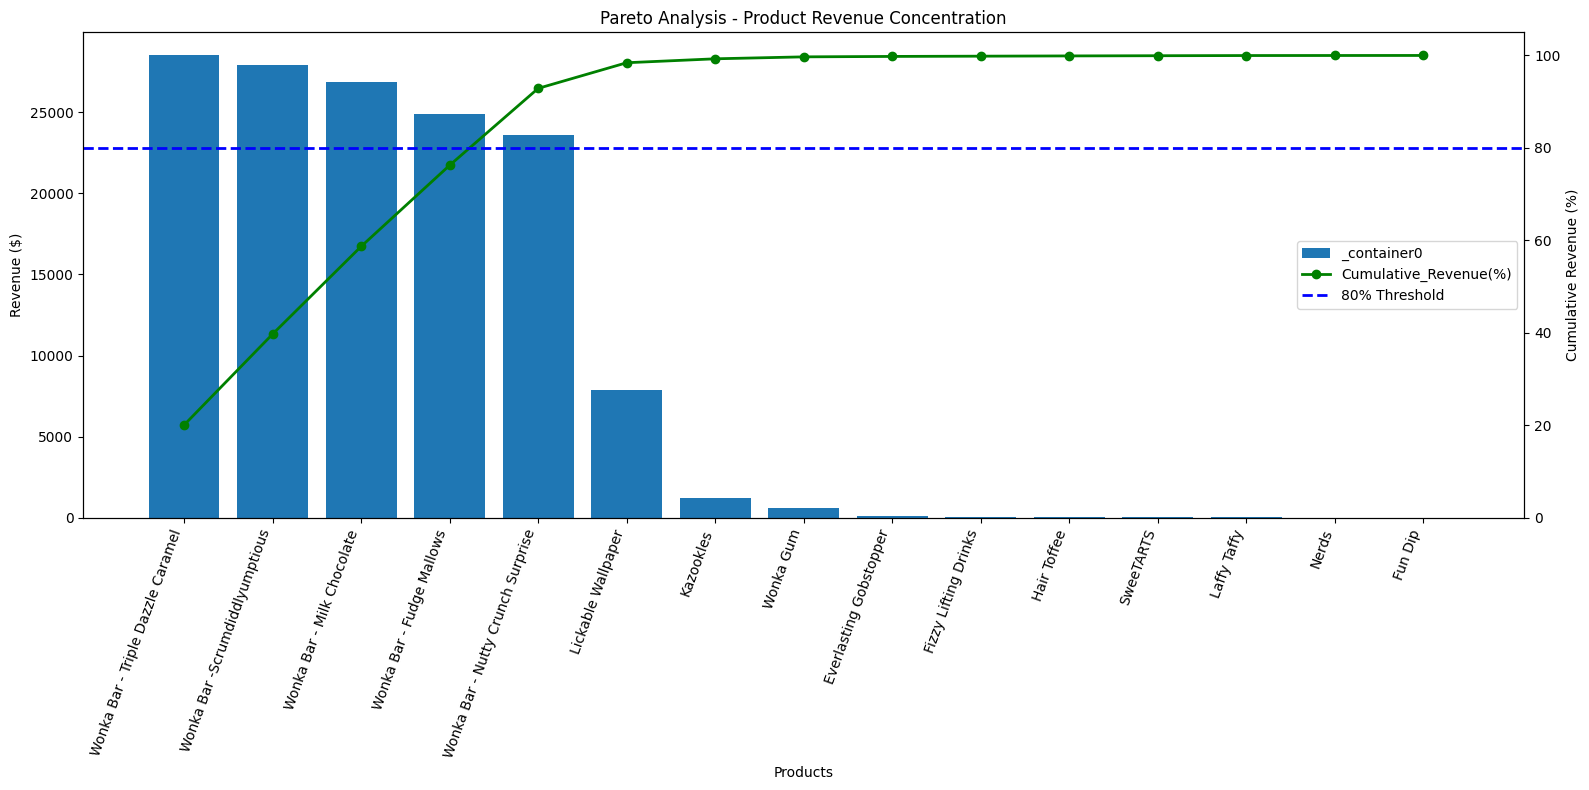

In [ ]:
fig, ax1 = plt.subplots(figsize=(16, 8))

x = np.arange(len(revenue_pareto))

bar = ax1.bar(
    x,
    revenue_pareto["Total_Sales"]
)

ax1.set_xlabel("Products")

ax1.set_ylabel("Revenue ($)")

ax1.set_title(
    "Pareto Analysis - Product Revenue Concentration"
)

ax1.set_xticks(x)

ax1.set_xticklabels(
    revenue_pareto["Product Name"],
    rotation=70,
    ha="right"
)

ax2 = ax1.twinx()

line, = ax2.plot(
    x,
    revenue_pareto["Cumulative_Revenue(%)"],
    marker="o",
    linewidth=2,
    color="green",
    label="Cumulative_Revenue(%)"
)

threshold = ax2.axhline(
    y=80,
    linestyle="--",
    linewidth=2,
    label="80% Threshold",
    color="blue"
)

ax2.set_ylabel("Cumulative Revenue (%)")

ax2.set_ylim(0, 105)

ax2.legend(
    handles=[bar, line, threshold],
    loc="center right"
)

plt.tight_layout()

plt.savefig(
    "Revenue_Pareto_Chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Profit Pareto Analysis

In [ ]:
profit_pareto = (
    df[
        [
            "Product ID",
            "Product Name",
            "Division",
            "Total_Gross_Profit"
        ]
    ].sort_values(
        by = "Total_Gross_Profit",
        ascending = False
    )
).reset_index(drop = True)

profit_pareto["Profit_Contribution(%)"] = (
    profit_pareto["Total_Gross_Profit"] / profit_pareto["Total_Gross_Profit"].sum()
)*100

profit_pareto["Cumulative_Profit(%)"] = (
    profit_pareto["Profit_Contribution(%)"].cumsum()
)

profit_pareto["Profit_Rank"] = (
    np.arange(1, len(profit_pareto) + 1)
)

display(profit_pareto)

,Product ID,Product Name,Division,Total_Gross_Profit,Profit_Contribution(%),Cumulative_Profit(%),Profit_Rank
0,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,Chocolate,19357.50,20.715882,20.715882,1
1,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,Chocolate,18610.20,19.916141,40.632023,2
2,CHO-MIL-31000,Wonka Bar - Milk Chocolate,Chocolate,17443.37,18.667431,59.299454,3
3,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,Chocolate,16819.95,18.000263,77.299717,4
4,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Chocolate,16593.60,17.758030,95.057747,5
5,OTH-LIC-15000,Lickable Wallpaper,Other,3930.00,4.205782,99.263528,6
6,OTH-GUM-21000,Wonka Gum,Other,310.70,0.332503,99.596031,7
7,SUG-EVE-47000,Everlasting Gobstopper,Sugar,104.00,0.111298,99.707329,8
8,OTH-KAZ-38000,Kazookles,Other,92.75,0.099259,99.806588,9
9,SUG-HAI-55000,Hair Toffee,Sugar,59.50,0.063675,99.870263,10


Find products required for 80% Profit

In [ ]:
profit_80_count =(
    profit_pareto["Cumulative_Profit(%)"] < 80
).sum() + 1

profit_80_products = profit_pareto.iloc[
    :profit_80_count
].copy()

profit_80_products_percentage = (
    profit_80_count / len(profit_pareto)
)*100

profit_80_actual_contribution = (
    profit_80_products["Total_Gross_Profit"].sum() / profit_pareto["Total_Gross_Profit"].sum()
)*100

print("Products Required to Reach 80% Profit: ", profit_80_count)

print("Percentage of Products Required to Reach 80% Profit: ", round(profit_80_products_percentage, 2), "%")

print("Actual Cumulative Profit Contribution: ", round(profit_80_actual_contribution, 2), "%")

display(
    profit_80_products[
        [
            "Product ID",
            "Product Name",
            "Division",
            "Total_Gross_Profit",
            "Profit_Contribution(%)",
            "Cumulative_Profit(%)"
        ]
    ]
)

Products Required to Reach 80% Profit:  5
Percentage of Products Required to Reach 80% Profit:  33.33 %
Actual Cumulative Profit Contribution:  95.06 %


,Product ID,Product Name,Division,Total_Gross_Profit,Profit_Contribution(%),Cumulative_Profit(%)
0,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,Chocolate,19357.50,20.715882,20.715882
1,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,Chocolate,18610.20,19.916141,40.632023
2,CHO-MIL-31000,Wonka Bar - Milk Chocolate,Chocolate,17443.37,18.667431,59.299454
3,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,Chocolate,16819.95,18.000263,77.299717
4,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Chocolate,16593.60,17.758030,95.057747


Profit Pareto Chart

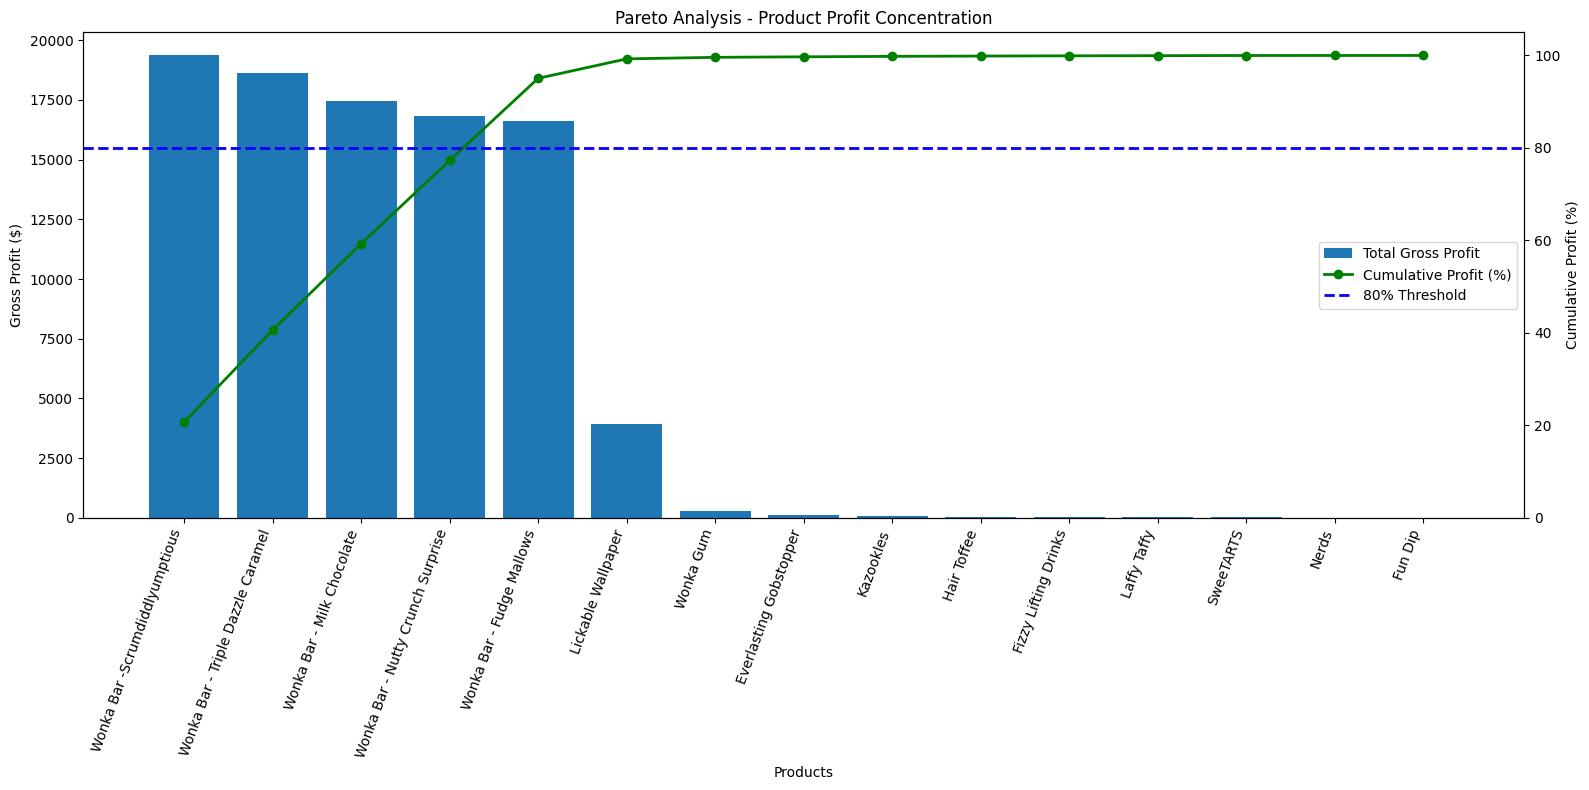

In [ ]:
fig, ax1 = plt.subplots(figsize=(16, 8))

x = np.arange(len(profit_pareto))

bar = ax1.bar(
    x,
    profit_pareto["Total_Gross_Profit"],
    label="Total Gross Profit"
)

ax1.set_xlabel("Products")
ax1.set_ylabel("Gross Profit ($)")

ax1.set_title(
    "Pareto Analysis - Product Profit Concentration"
)

ax1.set_xticks(x)

ax1.set_xticklabels(
    profit_pareto["Product Name"],
    rotation=70,
    ha="right"
)

ax2 = ax1.twinx()

line, = ax2.plot(
    x,
    profit_pareto["Cumulative_Profit(%)"],
    marker="o",
    linewidth=2,
    label="Cumulative Profit (%)",
    color="green"
)

threshold = ax2.axhline(
    y=80,
    linestyle="--",
    linewidth=2,
    label="80% Threshold",
    color = "blue"
)

ax2.set_ylabel("Cumulative Profit (%)")
ax2.set_ylim(0, 105)

ax1.legend(
    handles=[bar, line, threshold],
    loc="center right"
)

plt.tight_layout()

plt.savefig(
    "Profit_Pareto_Chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Identify the actual critical products

In [ ]:
critical_revenue_products = (
    set(
        revenue_80_products["Product Name"]
    )
)

critical_profit_products = (
    set(
        profit_80_products["Product Name"]
    )
)

critical_products = (
    critical_revenue_products.intersection(critical_profit_products)
)

print("Critical Products for Both Revenue and Profit:")
print()

for product in critical_products:
  print(product)

Critical Products for Both Revenue and Profit:

Wonka Bar - Fudge Mallows
Wonka Bar - Nutty Crunch Surprise
Wonka Bar -Scrumdiddlyumptious
Wonka Bar - Milk Chocolate
Wonka Bar - Triple Dazzle Caramel


Division dependency check. To check above actual critical products belongs to which Division.

In [ ]:
critical_products_details = (
    df[
        df["Product Name"].isin(critical_products)
    ][
        [
            "Product Name",
            "Division",
            "Total_Sales",
            "Total_Gross_Profit"
        ]
    ]
)

display(critical_products_details)

print("\nCritical Products by Division:")

display(
    critical_products_details["Division"].value_counts()
)

,Product Name,Division,Total_Sales,Total_Gross_Profit
0,Wonka Bar -Scrumdiddlyumptious,Chocolate,27874.80,19357.50
1,Wonka Bar - Triple Dazzle Caramel,Chocolate,28485.00,18610.20
2,Wonka Bar - Milk Chocolate,Chocolate,26867.75,17443.37
3,Wonka Bar - Nutty Crunch Surprise,Chocolate,23574.95,16819.95
4,Wonka Bar - Fudge Mallows,Chocolate,24890.40,16593.60



Critical Products by Division:


,count
Division,
Chocolate,5


Create Final Report Summary

In [ ]:
pareto_summary = pd.DataFrame(
    {
        "Metric": [
            "Total Products",
            "Total Revenue",
            "Product Required for 80% Revenue",
            "% Products Required for 80% Revenue",
            "Actual Revenue Contribution(%)",
            "Total Profit",
            "Product Required for 80% Profit",
            "% Products Required for 80% Profit",
            "Actual Profit Contribution(%)",
            "Common Critical Products",
            "Name of Common Critical Products",
            "Critical Products by Divisions"
        ],

        "Result": [
            len(df["Product Name"].unique()),
            df["Total_Sales"].sum(),
            revenue_80_count,
            round(revenue_80_products_percentage, 2),
            round(revenue_80_actual_contribution, 2),
            df["Total_Gross_Profit"].sum(),
            profit_80_count,
            round(profit_80_products_percentage, 2),
            round(profit_80_actual_contribution, 2),
            len(critical_products),
            " ,".join(critical_products_details["Product Name"]),
            " ,".join(critical_products_details["Division"])
        ]
    }
)

display(pareto_summary)

,Metric,Result
0,Total Products,15
1,Total Revenue,141783.63
2,Product Required for 80% Revenue,5
3,% Products Required for 80% Revenue,33.33
4,Actual Revenue Contribution(%),92.88
5,Total Profit,93442.8
6,Product Required for 80% Profit,5
7,% Products Required for 80% Profit,33.33
8,Actual Profit Contribution(%),95.06
9,Common Critical Products,5


Create Detailed Final Pareto CSV

In [ ]:
revenue_pareto.to_csv(
    "Renenue Pareto Report.csv",
    index = False
)

profit_pareto.to_csv(
    "Profit Pareto Report.csv",
    index = False
)

pareto_summary.to_csv(
    "Phase 3.4 Preto Analysis Summary Report.csv",
    index = False
)

print("Pareto Report Save Successfully")

Pareto Report Save Successfully


Download Report and Charts

In [ ]:
# Revenue Pareto Report

files.download("Renenue Pareto Report.csv")

# Profit Pareto Report

files.download("Profit Pareto Report.csv")

# Pareto Summary Perort

files.download("Phase 3.4 Preto Analysis Summary Report.csv")

# Revenue Chart

files.download("Revenue_Pareto_Chart.png")

# Profit Chart

files.download("Profit_Pareto_Chart.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

####State/Region Concentration & Over-Dependency Analysis




**State-Level Concentration**

In [ ]:
# Load Cleaned Dataset
upload_file = files.upload()

Saving Cleaned_Nassau_Candy_Distributor_Dataset.csv to Cleaned_Nassau_Candy_Distributor_Dataset.csv


In [ ]:
df_clean = pd.read_csv("Cleaned_Nassau_Candy_Distributor_Dataset.csv")

In [ ]:
df_clean.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost,Shipping Days,Flag_Invalid_Sales,Flag_Invalid_Units,Flag_Invalid_Cost,Flag_Invalid_Profit,Flag_Profit_Calculation,Flag_Shipping_Date,Flag_Shipping_Duration,Flag_Overall_Quality
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28,909,ok,Ok,Ok,Ok,Ok,Ok,Ok,Valid
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60,909,ok,Ok,Ok,Ok,Ok,Ok,Ok,Valid
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00,909,ok,Ok,Ok,Ok,Ok,Ok,Ok,Valid
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30,909,ok,Ok,Ok,Ok,Ok,Ok,Ok,Valid
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90,912,ok,Ok,Ok,Ok,Ok,Ok,Ok,Valid


State-wise aggregation

In [ ]:
state_analysis = (
    df_clean.groupby(
        "State/Province"
    ).agg(
        Total_Order = ("Order ID", "nunique"),
        Total_Units = ("Units", "sum"),
        Total_Sales = ("Sales", "sum"),
        Total_Gross_Profit = ("Gross Profit", "sum")
    ).reset_index()
)

display(state_analysis.head())

,State/Province,Total_Order,Total_Units,Total_Sales,Total_Gross_Profit
0,Alabama,53,256,995.11,622.11
1,Alberta,22,110,530.32,326.30
2,Arizona,190,862,3587.55,2290.11
3,Arkansas,48,240,891.94,588.02
4,British Columbia,22,81,290.90,198.30


Contribution percentages

In [ ]:
state_analysis["Order_Share(%)"] = (
    state_analysis["Total_Order"] / state_analysis["Total_Order"].sum()
)*100

state_analysis["Unit_Share(%)"] = (
    state_analysis["Total_Units"] / state_analysis["Total_Units"].sum()
)*100

state_analysis["Revenue_Share(%)"] = (
    state_analysis["Total_Sales"] / state_analysis["Total_Sales"].sum()
)*100

state_analysis["Profit_Share(%)"] = (
    state_analysis["Total_Gross_Profit"] / state_analysis["Total_Gross_Profit"].sum()
)*100

state_analysis.head()

,State/Province,Total_Order,Total_Units,Total_Sales,Total_Gross_Profit,Order_Share(%),Unit_Share(%),Revenue_Share(%),Profit_Share(%)
0,Alabama,53,256,995.11,622.11,0.619956,0.662286,0.701851,0.665766
1,Alberta,22,110,530.32,326.30,0.257340,0.284576,0.374035,0.349198
2,Arizona,190,862,3587.55,2290.11,2.222482,2.230041,2.530299,2.450815
3,Arkansas,48,240,891.94,588.02,0.561469,0.620893,0.629085,0.629283
4,British Columbia,22,81,290.90,198.30,0.257340,0.209551,0.205172,0.212215


Revenue Pareto By State/Province

In [ ]:
state_revenue_pareto = (
    state_analysis.sort_values("Total_Sales", ascending = False).reset_index(drop = True)
)

state_revenue_pareto["Cumulative_Revenue(%)"] = (
    state_revenue_pareto["Revenue_Share(%)"].cumsum()
)

state_revenue_pareto["Revenue_Rank"] = (
    np.arange(1, len(state_revenue_pareto) + 1)
)

display(
    state_revenue_pareto[
        [
            "State/Province",
            "Total_Sales",
            "Revenue_Share(%)",
            "Cumulative_Revenue(%)",
            "Revenue_Rank"
        ]
    ].head(10)
)

,State/Province,Total_Sales,Revenue_Share(%),Cumulative_Revenue(%),Revenue_Rank
0,California,27917.40,19.690143,19.690143,1
1,New York,15541.03,10.961089,30.651232,2
2,Texas,13416.09,9.462369,40.113601,3
3,Pennsylvania,8027.03,5.661465,45.775066,4
4,Washington,6921.15,4.881487,50.656553,5
5,Illinois,6898.96,4.865837,55.522390,6
6,Ohio,6768.95,4.774141,60.296531,7
7,Florida,4804.02,3.388276,63.684806,8
8,Arizona,3587.55,2.530299,66.215105,9
9,North Carolina,3450.86,2.433892,68.648997,10


80% Revenue Generated State

In [ ]:
state_revenue_80_count = (
    state_revenue_pareto["Cumulative_Revenue(%)"] < 80
).sum() + 1

state_revenue_80 = state_revenue_pareto.iloc[
    :state_revenue_80_count
]

state_revenue_80_percentage = (
    state_revenue_80_count
    / len(state_analysis)
) * 100

print(
    "States required to reach 80% Revenue:",
    state_revenue_80_count
)

print(
    f"Percentage of states: "
    f"{state_revenue_80_percentage:.2f}%"
)

print(
    f"Actual Revenue Contribution: "
    f"{state_revenue_80["Revenue_Share(%)"].sum():.2f}%"
)

state_revenue_80.head()

States required to reach 80% Revenue: 16
Percentage of states: 27.12%
Actual Revenue Contribution: 80.03%


,State/Province,Total_Order,Total_Units,Total_Sales,Total_Gross_Profit,Order_Share(%),Unit_Share(%),Revenue_Share(%),Profit_Share(%),Cumulative_Revenue(%),Revenue_Rank
0,California,1686,7667,27917.40,18479.42,19.721605,19.834946,19.690143,19.776184,19.690143,1
1,New York,942,4224,15541.03,10222.44,11.018833,10.927718,10.961089,10.939783,30.651232,2
2,Texas,833,3724,13416.09,8909.53,9.743830,9.634191,9.462369,9.534742,40.113601,3
3,Pennsylvania,487,2153,8027.03,5225.47,5.696573,5.569928,5.661465,5.592159,45.775066,4
4,Washington,432,1883,6921.15,4566.64,5.053223,4.871423,4.881487,4.887097,50.656553,5


Profit Pareto by State/Province

In [ ]:
state_profit_pareto = (
    state_analysis.sort_values("Total_Gross_Profit", ascending = False).reset_index(drop = True)
)

state_profit_pareto["Cumulative_Profit(%)"] = (
    state_profit_pareto["Profit_Share(%)"].cumsum()
)

state_profit_pareto["Profit_Rank"] = (
    np.arange(1, len(state_profit_pareto) + 1)
)

display(
    state_profit_pareto[
        [
            "State/Province",
            "Total_Gross_Profit",
            "Profit_Share(%)",
            "Cumulative_Profit(%)",
            "Profit_Rank"
        ]
    ].head(10)
)

,State/Province,Total_Gross_Profit,Profit_Share(%),Cumulative_Profit(%),Profit_Rank
0,California,18479.42,19.776184,19.776184,1
1,New York,10222.44,10.939783,30.715967,2
2,Texas,8909.53,9.534742,40.250710,3
3,Pennsylvania,5225.47,5.592159,45.842869,4
4,Washington,4566.64,4.887097,50.729965,5
5,Illinois,4557.68,4.877508,55.607473,6
6,Ohio,4413.03,4.722707,60.330181,7
7,Florida,3207.11,3.432164,63.762344,8
8,North Carolina,2331.16,2.494745,66.257090,9
9,Arizona,2290.11,2.450815,68.707905,10


80% Profit Generated State/Province

In [ ]:
state_profit_80_count = (
    state_profit_pareto["Cumulative_Profit(%)"] < 80
).sum() + 1

state_profit_80 = (
    state_profit_pareto.iloc[:state_profit_80_count]
)

state_profit_80_percentage = (
    state_revenue_80_count / len(state_profit_pareto)
)*100

print(
    "States required to reach 80% profit:",
    state_profit_80_count
)

print(
    f"Percentage of states: "
    f"{state_profit_80_percentage:.2f}%"
)

print(
    f"Actual Pprofit Contribution: "
    f"{state_profit_80["Profit_Share(%)"].sum():.2f}%"
)

States required to reach 80% profit: 16
Percentage of states: 27.12%
Actual Pprofit Contribution: 80.14%


Top State/Provience by Operational Load

In [ ]:
top_states = (
    state_analysis.sort_values("Total_Sales", ascending = False)
)

display(
    top_states[
        [
            "State/Province",
            "Total_Order",
            "Total_Units",
            "Order_Share(%)",
            "Unit_Share(%)",
            "Revenue_Share(%)",
            "Profit_Share(%)"
        ]
    ].head(10).reset_index(drop = True)
)

,State/Province,Total_Order,Total_Units,Order_Share(%),Unit_Share(%),Revenue_Share(%),Profit_Share(%)
0,California,1686,7667,19.721605,19.834946,19.690143,19.776184
1,New York,942,4224,11.018833,10.927718,10.961089,10.939783
2,Texas,833,3724,9.743830,9.634191,9.462369,9.534742
3,Pennsylvania,487,2153,5.696573,5.569928,5.661465,5.592159
4,Washington,432,1883,5.053223,4.871423,4.881487,4.887097
5,Illinois,433,1845,5.064920,4.773115,4.865837,4.877508
6,Ohio,392,1759,4.585332,4.550629,4.774141,4.722707
7,Florida,319,1379,3.731431,3.567548,3.388276,3.432164
8,Arizona,190,862,2.222482,2.230041,2.530299,2.450815
9,North Carolina,216,983,2.526611,2.543074,2.433892,2.494745


Potential Congestion-Prone State Flag.
* 90th percentile operational workload used.

In [ ]:
order_threshold = (
    state_analysis["Total_Order"].quantile(0.90)
)

units_threshold = (
    state_analysis["Total_Units"].quantile(0.90)
)

print("90th Percentile Order Threshold: ", order_threshold)
print("90th Percentile Units Threshold: ", units_threshold)

state_analysis["Potential_Congestion_Risk"] = (
    np.where(
        (state_analysis["Total_Order"] >= order_threshold) |
        (state_analysis["Total_Units"] >= units_threshold),
        "High Load",
        "Normal Load"
    )
)

high_load_state = state_analysis[
    state_analysis["Potential_Congestion_Risk"] == "High Load"
].sort_values(
    "Total_Order",
    ascending = False
)

display(
    high_load_state[
        [
            "State/Province",
            "Total_Order",
            "Total_Units",
            "Order_Share(%)",
            "Unit_Share(%)",
            "Potential_Congestion_Risk"
        ]
    ]
)

90th Percentile Order Threshold:  400.0000000000001
90th Percentile Units Threshold:  1776.2000000000003


,State/Province,Total_Order,Total_Units,Order_Share(%),Unit_Share(%),Potential_Congestion_Risk
5,California,1686,7667,19.721605,19.834946,High Load
34,New York,942,4224,11.018833,10.927718,High Load
51,Texas,833,3724,9.743830,9.634191,High Load
43,Pennsylvania,487,2153,5.696573,5.569928,High Load
13,Illinois,433,1845,5.064920,4.773115,High Load
55,Washington,432,1883,5.053223,4.871423,High Load


**Region-Level Concentration**

Region Aggregation

In [ ]:
df_clean.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Country/Region', 'City', 'State/Province',
       'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name',
       'Sales', 'Units', 'Gross Profit', 'Cost', 'Shipping Days',
       'Flag_Invalid_Sales', 'Flag_Invalid_Units', 'Flag_Invalid_Cost',
       'Flag_Invalid_Profit', 'Flag_Profit_Calculation', 'Flag_Shipping_Date',
       'Flag_Shipping_Duration', 'Flag_Overall_Quality'],
      dtype='object')

In [ ]:
region_analysis = (
    df_clean.groupby(
        "Region"
    ).agg(
        Total_Order = ("Order ID", "nunique"),
        Total_Units = ("Units", "sum"),
        Total_Sales = ("Sales", "sum"),
        Total_Gross_Profit = ("Gross Profit", "sum")
    ).reset_index()
)

region_analysis.head()

,Region,Total_Order,Total_Units,Total_Sales,Total_Gross_Profit
0,Atlantic,2476,11159,41197.24,26973.70
1,Gulf,1350,6209,22247.26,14700.67
2,Interior,1979,8820,32037.60,21282.49
3,Pacific,2744,12466,46301.53,30485.94


Contribution Percentages

In [ ]:
region_analysis["Order_Share(%)"] = (
    region_analysis["Total_Order"] / region_analysis["Total_Order"].sum()
)*100

region_analysis["Units_Share(%)"] = (
    region_analysis["Total_Units"] / region_analysis["Total_Units"].sum()
)*100

region_analysis["Revenue_Share(%)"] = (
    region_analysis["Total_Sales"] / region_analysis["Total_Sales"].sum()
)*100

region_analysis["Profit_Share(%)"] = (
    region_analysis["Total_Gross_Profit"] / region_analysis["Total_Gross_Profit"].sum()
)*100

region_analysis = region_analysis.sort_values(
    "Total_Sales",
    ascending = False
).reset_index(drop = True)

region_analysis.head()

,Region,Total_Order,Total_Units,Total_Sales,Total_Gross_Profit,Order_Share(%),Units_Share(%),Revenue_Share(%),Profit_Share(%)
0,Pacific,2744,12466,46301.53,30485.94,32.097321,32.250220,32.656471,32.625242
1,Atlantic,2476,11159,41197.24,26973.70,28.962452,28.868940,29.056415,28.866537
2,Interior,1979,8820,32037.60,21282.49,23.148906,22.817820,22.596121,22.775955
3,Gulf,1350,6209,22247.26,14700.67,15.791321,16.063021,15.690993,15.732266


Identify high-load regions

In [ ]:
average_region_order_share = 100 / len(region_analysis)

print(
    f"Average Region Order Share:"
    f"{average_region_order_share:.2f}%"
)

Average Region Order Share:25.00%


High Load Region

In [ ]:
region_analysis["Potential_Congestion_Risk"] = (
    np.where(
        (region_analysis["Order_Share(%)"] >= average_region_order_share) &
        (region_analysis["Units_Share(%)"] >= average_region_order_share),
        "High Load",
        "Normal Load"
    )
)

display(region_analysis)

,Region,Total_Order,Total_Units,Total_Sales,Total_Gross_Profit,Order_Share(%),Units_Share(%),Revenue_Share(%),Profit_Share(%),Potential_Congestion_Risk
0,Pacific,2744,12466,46301.53,30485.94,32.097321,32.250220,32.656471,32.625242,High Load
1,Atlantic,2476,11159,41197.24,26973.70,28.962452,28.868940,29.056415,28.866537,High Load
2,Interior,1979,8820,32037.60,21282.49,23.148906,22.817820,22.596121,22.775955,Normal Load
3,Gulf,1350,6209,22247.26,14700.67,15.791321,16.063021,15.690993,15.732266,Normal Load


Region 80% Pareto

In [ ]:
region_analysis["Cumulative_Revenue(%)"] = (
    region_analysis["Revenue_Share(%)"].cumsum()
)

region_80_count = (
    region_analysis["Cumulative_Revenue(%)"] < 80
).sum() + 1

print(
    "Regions required for 80% Revenue:",
    region_80_count
)

print(
    f"Percentage of Regions: "
    f"{region_80_count / len(region_analysis) * 100:.2f}%"
)

Regions required for 80% Revenue: 3
Percentage of Regions: 75.00%


State Revenue Pareto Chart

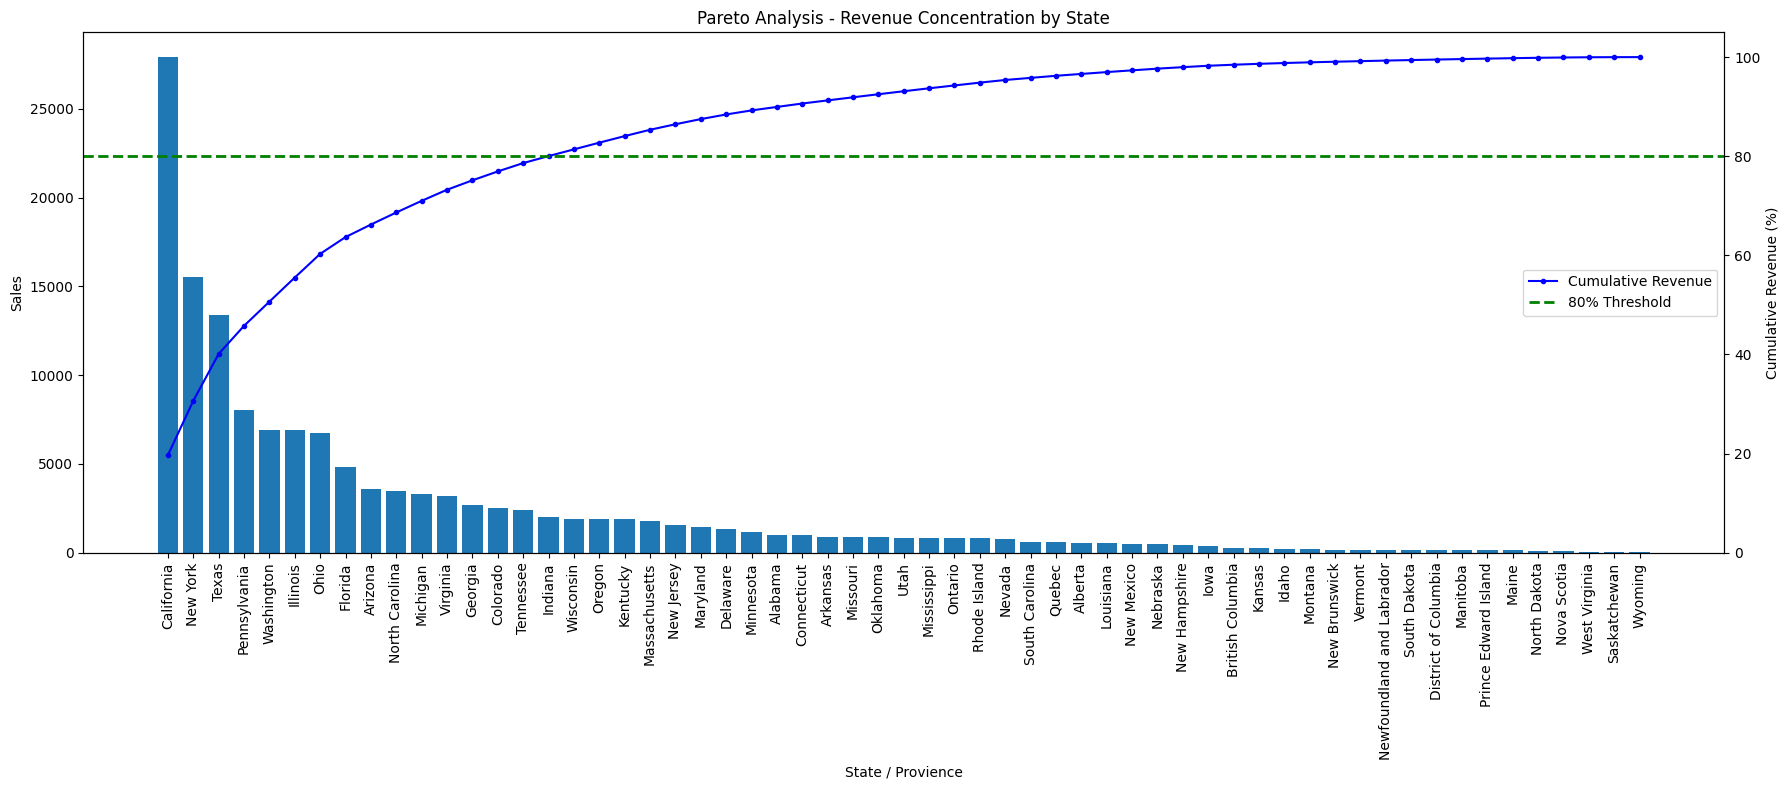

In [ ]:
state_chart = (
    state_revenue_pareto.sort_values(
        "Total_Sales",
        ascending = False
    ).reset_index(drop = True)
)

fig, ax1 = plt.subplots(figsize = (18, 8))

x = np.arange(len(state_chart))

bar = ax1.bar(
    x,
    state_chart["Total_Sales"]
)

ax1.set_xlabel("State / Provience")
ax1.set_ylabel("Sales")

ax1.set_title("Pareto Analysis - Revenue Concentration by State")

ax1.set_xticks(x)

ax1.set_xticklabels(
    state_chart["State/Province"],
    rotation=90
)

ax2 = ax1.twinx()

line, = ax2.plot(
    x,
    state_chart["Cumulative_Revenue(%)"],
    marker="o",
    markersize=3,
    label="Cumulative Revenue",
    color = "blue"
)

threshols = ax2.axhline(
    y=80,
    linestyle="--",
    linewidth=2,
    label="80% Threshold",
    color = "green"
)

ax2.set_ylabel("Cumulative Revenue (%)")
ax2.set_ylim(0, 105)

ax2.legend(
    handles=[line, threshols],
    loc="center right"
)

plt.tight_layout()

plt.savefig(
    "State_Revenue_Pareto.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Region workload chart

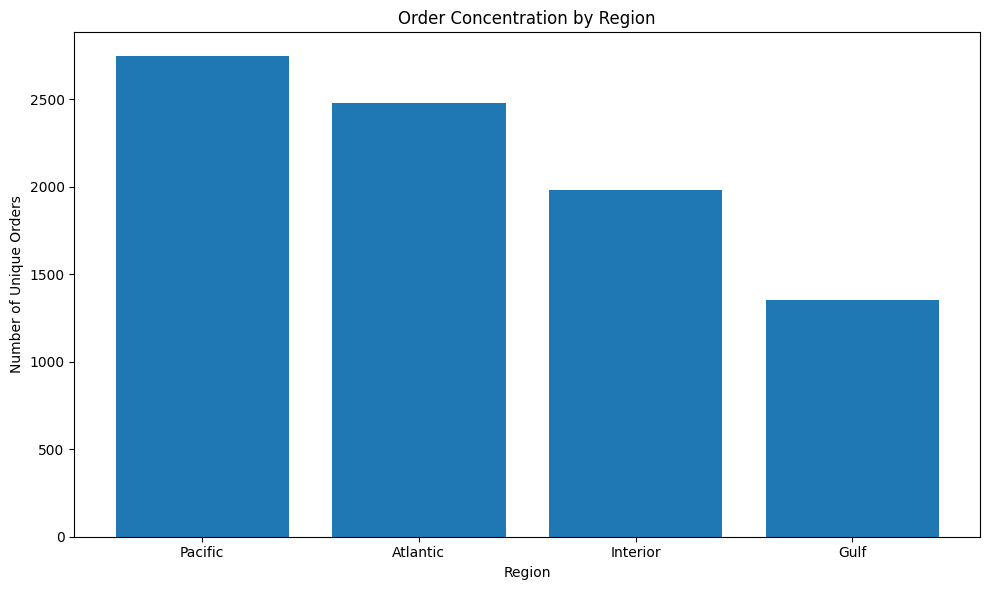

In [ ]:
region_plot = (
    region_analysis
    .sort_values(
        "Total_Order",
        ascending=False
    )
)

plt.figure(figsize=(10, 6))

plt.bar(
    region_plot["Region"],
    region_plot["Total_Order"]
)

plt.title(
    "Order Concentration by Region"
)

plt.xlabel("Region")
plt.ylabel("Number of Unique Orders")

plt.tight_layout()

plt.savefig(
    "Region_Order_Concentration.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Create Over-Dependency Risk
* state level

In [ ]:
state_dependency_ratio = (
    state_revenue_80_count
    / len(state_analysis)
) * 100

if state_dependency_ratio <= 30:
    state_dependency_risk = "High"
elif state_dependency_ratio <= 50:
    state_dependency_risk = "Moderate"
else:
    state_dependency_risk = "Low"

print(
    "State Over-Dependency Risk:",
    state_dependency_risk
)

State Over-Dependency Risk: High


Final summary report

In [ ]:
geo_summary = pd.DataFrame({

    "Metric": [
        "Total States/Provinces",
        "States Required for 80% Revenue",
        "% States Driving 80% Revenue",
        "Actual Revenue Contribution (%)",

        "States Required for 80% Profit",
        "Actual Profit Contribution (%)",

        "Top Revenue State",
        "Top Order State",

        "Top Region",
        "Top Region Revenue Share (%)",
        "Top Region Order Share (%)",

        "Regions Required for 80% Revenue",

        "State Dependency Risk",
        "Potential Highest-Load Region"
    ],

    "Result": [
        len(state_analysis),

        state_revenue_80_count,
        round(state_revenue_80_percentage, 2),
        round(
            state_revenue_80[
                "Revenue_Share(%)"
            ].sum(), 2
        ),

        state_profit_80_count,
        round(
            state_profit_80[
                "Profit_Share(%)"
            ].sum(), 2
        ),

        state_analysis.loc[
            state_analysis[
                "Total_Sales"
            ].idxmax(),
            "State/Province"
        ],

        state_analysis.loc[
            state_analysis[
                "Total_Order"
            ].idxmax(),
            "State/Province"
        ],

        region_analysis.iloc[0]["Region"],
        round(
            region_analysis.iloc[0][
                "Revenue_Share(%)"
            ], 2
        ),

        round(
            region_analysis.iloc[0][
                "Order_Share(%)"
            ], 2
        ),

        region_80_count,

        state_dependency_risk,

        region_analysis.sort_values(
            "Total_Order",
            ascending=False
        ).iloc[0]["Region"]
    ]
})

display(geo_summary)

,Metric,Result
0,Total States/Provinces,59
1,States Required for 80% Revenue,16
2,% States Driving 80% Revenue,27.12
3,Actual Revenue Contribution (%),80.03
4,States Required for 80% Profit,16
5,Actual Profit Contribution (%),80.14
6,Top Revenue State,California
7,Top Order State,California
8,Top Region,Pacific
9,Top Region Revenue Share (%),32.66


In [ ]:
state_analysis.to_csv(
    "State_Concentration_Analysis.csv",
    index=False
)

region_analysis.to_csv(
    "Region_Concentration_Analysis.csv",
    index=False
)

geo_summary.to_csv(
    "Phase_3.4_State Concentration & Over-Dependency Analysis_Summary.csv",
    index=False
)

Downloaded Report and Chart

In [ ]:
files.download("State_Concentration_Analysis.csv")
files.download("Region_Concentration_Analysis.csv")
files.download("Phase_3.4_State Concentration & Over-Dependency Analysis_Summary.csv")
files.download("State_Revenue_Pareto.png")
files.download("Region_Order_Concentration.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

###**Cost Structure Diagnostics**
* Cost vs sales scatter analysis
* **Identify:**
  * Cost-heavy, margin-poor products
  * Pricing inefficiencies
* **Flag products needing:**
  * Repricing
  * Cost renegotiation
  * Discontinuation review

Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Load Dataset

In [ ]:
from google.colab import files
upload_file = files.upload()

Saving Phase_3.2_Product_Level_Profitability_Analysis.csv to Phase_3.2_Product_Level_Profitability_Analysis.csv


In [ ]:
product_df = pd.read_csv("Phase_3.2_Product_Level_Profitability_Analysis.csv")

In [ ]:
product_df.head(1)

,Product ID,Product Name,Division,Total_Sales,Total_Units,Total_Cost,Total_Gross_Profit,Gross_Margin(%),Profit_per_Unit,Total_Profit_Contribution,Gross_Profit_Rank,Gross_Margin_Rank,Profitability_Category
0,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,Chocolate,27874.8,7743,8517.3,19357.5,69.444444,2.5,0.207159,1,4,High Profit High Margin


Calculate Sale per Unit

In [ ]:
product_df["Sales_per_Unit"] = product_df["Total_Sales"] / product_df["Total_Units"]

Calculate Cost per Unit

In [ ]:
product_df["Cost_per_Unit"] = product_df["Total_Cost"] / product_df["Total_Units"]

Calculate Cost Ratio

In [ ]:
product_df["Cost_Ratio(%)"] = (
    product_df["Total_Cost"] / product_df["Total_Sales"]
)*100

Price-Cost Gap

In [ ]:
product_df["Price_Cost_Gap"] = (
    product_df["Sales_per_Unit"] - product_df["Cost_per_Unit"]
)

Markup on Cost

In [ ]:
product_df["Markup_on_Cost(%)"] = np.where(
    product_df["Cost_per_Unit"] > 0,
    (product_df["Price_Cost_Gap"] / product_df["Cost_per_Unit"]) * 100,
    np.nan
)

In [ ]:
product_cost = product_df.copy()
product_cost[
    [
        "Product Name",
        "Total_Cost",
        "Total_Sales",
        "Gross_Margin(%)",
        "Profit_per_Unit",
        "Sales_per_Unit",
        "Cost_per_Unit",
        "Cost_Ratio(%)",
        "Price_Cost_Gap",
        "Markup_on_Cost(%)"
    ]
].round(2)

,Product Name,Total_Cost,Total_Sales,Gross_Margin(%),Profit_per_Unit,Sales_per_Unit,Cost_per_Unit,Cost_Ratio(%),Price_Cost_Gap,Markup_on_Cost(%)
0,Wonka Bar -Scrumdiddlyumptious,8517.30,27874.80,69.44,2.50,3.60,1.10,30.56,2.50,227.27
1,Wonka Bar - Triple Dazzle Caramel,9874.80,28485.00,65.33,2.45,3.75,1.30,34.67,2.45,188.46
2,Wonka Bar - Milk Chocolate,9424.38,26867.75,64.92,2.11,3.25,1.14,35.08,2.11,185.09
3,Wonka Bar - Nutty Crunch Surprise,6755.00,23574.95,71.35,2.49,3.49,1.00,28.65,2.49,249.00
4,Wonka Bar - Fudge Mallows,8296.80,24890.40,66.67,2.40,3.60,1.20,33.33,2.40,200.00
5,Lickable Wallpaper,3930.00,7860.00,50.00,10.00,20.00,10.00,50.00,10.00,100.00
6,Wonka Gum,286.80,597.50,52.00,0.65,1.25,0.60,48.00,0.65,108.33
7,Everlasting Gobstopper,26.00,130.00,80.00,8.00,10.00,2.00,20.00,8.00,400.00
8,Kazookles,1113.00,1205.75,7.69,0.25,3.25,3.00,92.31,0.25,8.33
9,Hair Toffee,17.00,76.50,77.78,3.50,4.50,1.00,22.22,3.50,350.00


Cost vs sales scatter analysis

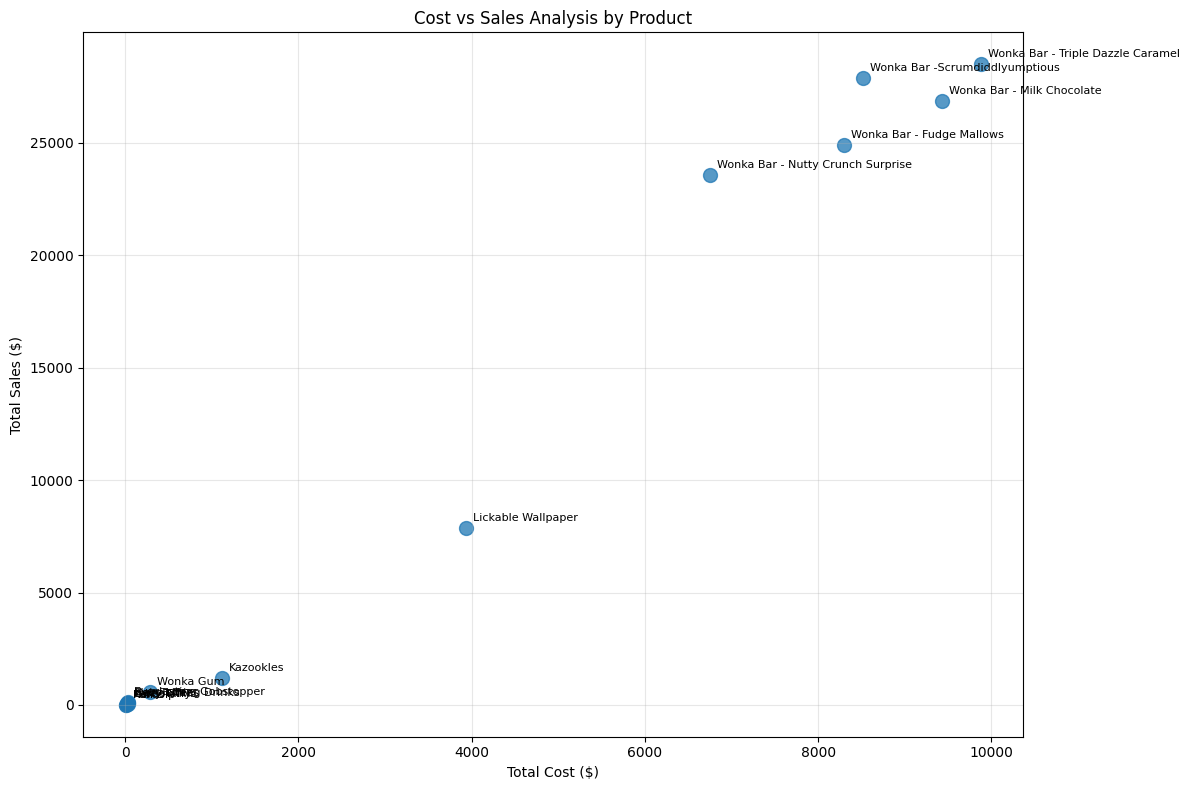

In [ ]:
plt.figure(figsize=(12, 8))

plt.scatter(
    product_cost["Total_Cost"],
    product_cost["Total_Sales"],
    s=100,
    alpha=0.75
)

for _, row in product_cost.iterrows():

    plt.annotate(
        row["Product Name"],
        (
            row["Total_Cost"],
            row["Total_Sales"]
        ),
        fontsize=8,
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.title(
    "Cost vs Sales Analysis by Product"
)

plt.xlabel("Total Cost ($)")
plt.ylabel("Total Sales ($)")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "Cost_vs_Sales_Scatter.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Create Diagnostic Threshold

In [ ]:
low_margin_threshold = product_cost["Gross_Margin(%)"].quantile(0.25)

high_cost_threshold = product_cost["Cost_Ratio(%)"].quantile(0.75)

low_sales_threshold = product_cost["Total_Sales"].quantile(0.25)

median_sales_threshold = product_cost["Total_Sales"].quantile(0.50)

low_profit_threshold = product_cost["Total_Gross_Profit"].quantile(0.25)


print("Low Margin Threshold: ", round(low_margin_threshold, 2), "%")
print("High Cost Ratio Threshold: ", round(high_cost_threshold, 2), "%")
print("Low Sales Threshold:", round(low_sales_threshold, 2))
print("Median Sales Threshold: ", round(median_sales_threshold, 2))
print("Low Profit Threshold: ", round(low_profit_threshold, 2))

Low Margin Threshold:  48.33 %
High Cost Ratio Threshold:  51.67 %
Low Sales Threshold: 69.0
Median Sales Threshold:  597.5
Low Profit Threshold:  40.36


Cost-Heavy, Margin-Poor Products

In [ ]:
product_cost["Cost_Heavy"] = product_cost["Cost_Ratio(%)"] >= high_cost_threshold

product_cost["Margin_Poor"] = product_cost["Gross_Margin(%)"] <= low_margin_threshold

cost_heavy_margin_poor = product_cost[
    (product_cost["Cost_Heavy"] == True)&
    (product_cost["Margin_Poor"] == True)
].round(2).copy()

cost_heavy_margin_poor


,Product ID,Product Name,Division,Total_Sales,Total_Units,Total_Cost,Total_Gross_Profit,Gross_Margin(%),Profit_per_Unit,Total_Profit_Contribution,Gross_Profit_Rank,Gross_Margin_Rank,Profitability_Category,Sales_per_Unit,Cost_per_Unit,Cost_Ratio(%),Price_Cost_Gap,Markup_on_Cost(%),Cost_Heavy,Margin_Poor
8,OTH-KAZ-38000,Kazookles,Other,1205.75,371,1113.0,92.75,7.69,0.25,0.0,9,14,High Sales Low Margin,3.25,3.0,92.31,0.25,8.33,True,True
12,SUG-SWE-91000,SweeTARTS,Sugar,61.50,41,32.8,28.70,46.67,0.70,0.0,13,12,Low Sales Low Profit,1.50,0.8,53.33,0.70,87.50,True,True
13,SUG-NER-92000,Nerds,Sugar,15.00,10,8.0,7.00,46.67,0.70,0.0,14,12,Low Sales Low Profit,1.50,0.8,53.33,0.70,87.50,True,True
14,SUG-FUN-75000,Fun Dip,Sugar,12.00,8,7.2,4.80,40.00,0.60,0.0,15,13,Low Sales Low Profit,1.50,0.9,60.00,0.60,66.67,True,True


Cost Ratio vs Margin Diagnostic Chart

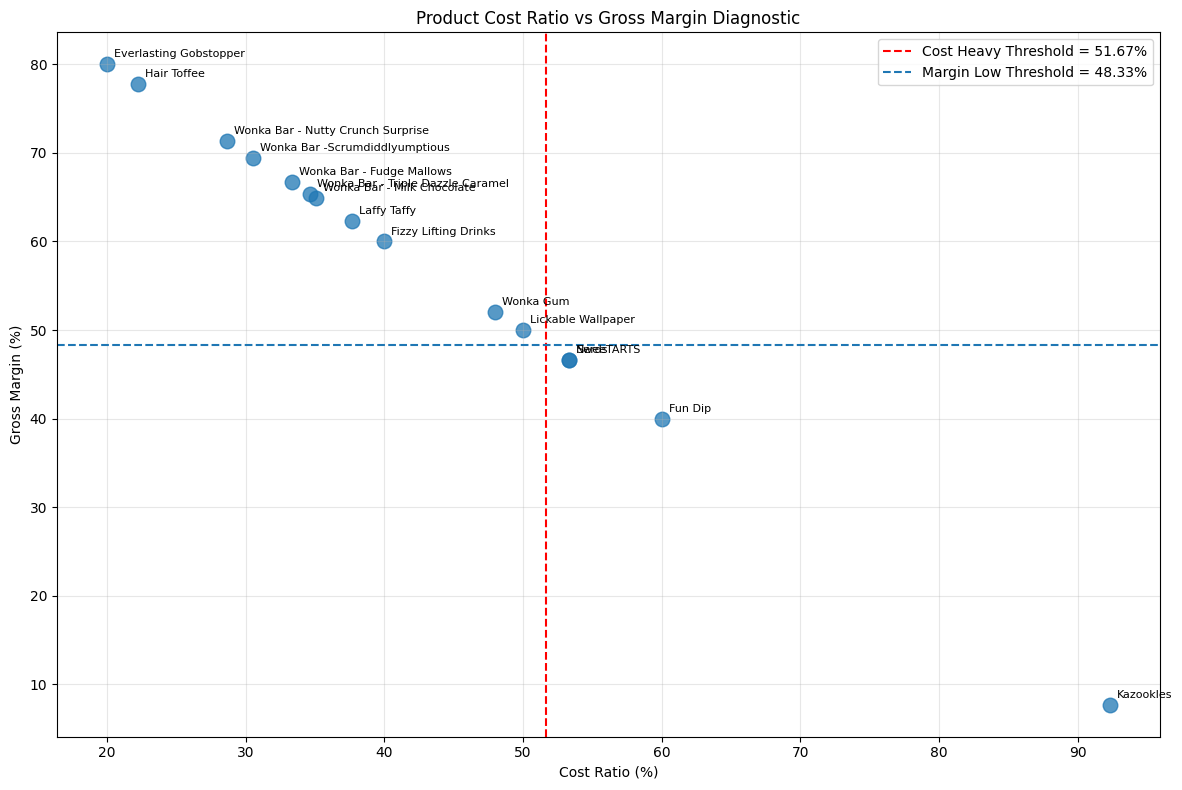

In [ ]:
plt.figure(figsize=(12, 8))

plt.scatter(
    product_cost["Cost_Ratio(%)"],
    product_cost["Gross_Margin(%)"],
    s=110,
    alpha=0.75
)

for _, row in product_cost.iterrows():

    plt.annotate(
        row["Product Name"],
        (
            row["Cost_Ratio(%)"],
            row["Gross_Margin(%)"]
        ),
        fontsize=8,
        xytext=(5, 5),
        textcoords="offset points"
    )

# Threshold lines
plt.axvline(
    x=51.67,
    linestyle="--",
    color = "red",
    label="Cost Heavy Threshold = 51.67%"
)

plt.axhline(
    y=48.33,
    linestyle="--",
    label="Margin Low Threshold = 48.33%"
)

plt.title(
    "Product Cost Ratio vs Gross Margin Diagnostic"
)

plt.xlabel("Cost Ratio (%)")
plt.ylabel("Gross Margin (%)")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "Cost_Ratio_vs_Gross_Margin.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Pricing inefficiencies

In [ ]:
product_cost["Pricing_Inefficiencies"] = (
    (product_cost["Gross_Margin(%)"] <= low_margin_threshold) &
    (product_cost["Total_Sales"] >= median_sales_threshold)
)

pricing_inefficiencies = product_cost[
    (product_cost["Pricing_Inefficiencies"] == True)
].copy()

pricing_inefficiencies.round(2)

,Product ID,Product Name,Division,Total_Sales,Total_Units,Total_Cost,Total_Gross_Profit,Gross_Margin(%),Profit_per_Unit,Total_Profit_Contribution,...,Gross_Margin_Rank,Profitability_Category,Sales_per_Unit,Cost_per_Unit,Cost_Ratio(%),Price_Cost_Gap,Markup_on_Cost(%),Cost_Heavy,Margin_Poor,Pricing_Inefficiencies
8,OTH-KAZ-38000,Kazookles,Other,1205.75,371,1113.0,92.75,7.69,0.25,0.0,...,14,High Sales Low Margin,3.25,3.0,92.31,0.25,8.33,True,True,True


Repricing Flag

In [ ]:
product_cost["Repricing_Flag"] = (
    (product_cost["Gross_Margin(%)"] <= low_margin_threshold) &
    (product_cost["Total_Sales"] >= median_sales_threshold)
)

repricing_flag = product_cost[
    (product_cost["Repricing_Flag"] == True)
].copy()

repricing_flag.round(2)

,Product ID,Product Name,Division,Total_Sales,Total_Units,Total_Cost,Total_Gross_Profit,Gross_Margin(%),Profit_per_Unit,Total_Profit_Contribution,...,Profitability_Category,Sales_per_Unit,Cost_per_Unit,Cost_Ratio(%),Price_Cost_Gap,Markup_on_Cost(%),Cost_Heavy,Margin_Poor,Pricing_Inefficiencies,Repricing_Flag
8,OTH-KAZ-38000,Kazookles,Other,1205.75,371,1113.0,92.75,7.69,0.25,0.0,...,High Sales Low Margin,3.25,3.0,92.31,0.25,8.33,True,True,True,True


Cost renegotiation Flag

In [ ]:
product_cost["Cost_Renegotiation_Flag"] = (
    (product_cost["Cost_Ratio(%)"] >= high_cost_threshold) &
    (product_cost["Gross_Margin(%)"] <= low_margin_threshold)
)

cost_renegotiation_flag = product_cost[
    (product_cost["Cost_Renegotiation_Flag"] == True)
].copy()

cost_renegotiation_flag.round(2)

,Product ID,Product Name,Division,Total_Sales,Total_Units,Total_Cost,Total_Gross_Profit,Gross_Margin(%),Profit_per_Unit,Total_Profit_Contribution,...,Sales_per_Unit,Cost_per_Unit,Cost_Ratio(%),Price_Cost_Gap,Markup_on_Cost(%),Cost_Heavy,Margin_Poor,Pricing_Inefficiencies,Repricing_Flag,Cost_Renegotiation_Flag
8,OTH-KAZ-38000,Kazookles,Other,1205.75,371,1113.0,92.75,7.69,0.25,0.0,...,3.25,3.0,92.31,0.25,8.33,True,True,True,True,True
12,SUG-SWE-91000,SweeTARTS,Sugar,61.50,41,32.8,28.70,46.67,0.70,0.0,...,1.50,0.8,53.33,0.70,87.50,True,True,False,False,True
13,SUG-NER-92000,Nerds,Sugar,15.00,10,8.0,7.00,46.67,0.70,0.0,...,1.50,0.8,53.33,0.70,87.50,True,True,False,False,True
14,SUG-FUN-75000,Fun Dip,Sugar,12.00,8,7.2,4.80,40.00,0.60,0.0,...,1.50,0.9,60.00,0.60,66.67,True,True,False,False,True


 Discontinuation review Flag

In [ ]:
product_cost["Discontinuation_Review_Flag"] = (
    (product_cost["Total_Sales"] <= low_sales_threshold) &
    (product_cost["Total_Gross_Profit"] <= low_profit_threshold) &
    (product_cost["Gross_Margin(%)"] <= low_margin_threshold)
)

discontinuation_review_flag = product_cost[
    (product_cost["Discontinuation_Review_Flag"] == True)
].copy()

discontinuation_review_flag.round(2)

,Product ID,Product Name,Division,Total_Sales,Total_Units,Total_Cost,Total_Gross_Profit,Gross_Margin(%),Profit_per_Unit,Total_Profit_Contribution,...,Cost_per_Unit,Cost_Ratio(%),Price_Cost_Gap,Markup_on_Cost(%),Cost_Heavy,Margin_Poor,Pricing_Inefficiencies,Repricing_Flag,Cost_Renegotiation_Flag,Discontinuation_Review_Flag
12,SUG-SWE-91000,SweeTARTS,Sugar,61.5,41,32.8,28.7,46.67,0.7,0.0,...,0.8,53.33,0.7,87.50,True,True,False,False,True,True
13,SUG-NER-92000,Nerds,Sugar,15.0,10,8.0,7.0,46.67,0.7,0.0,...,0.8,53.33,0.7,87.50,True,True,False,False,True,True
14,SUG-FUN-75000,Fun Dip,Sugar,12.0,8,7.2,4.8,40.00,0.6,0.0,...,0.9,60.00,0.6,66.67,True,True,False,False,True,True


In [ ]:
product_cost[
    [
        "Product Name",
        "Total_Cost",
        "Total_Sales",
        "Total_Gross_Profit",
        "Gross_Margin(%)",
        "Cost_Ratio(%)",
        "Repricing_Flag",
        "Cost_Renegotiation_Flag",
        "Discontinuation_Review_Flag"
    ]
]

,Product Name,Total_Cost,Total_Sales,Total_Gross_Profit,Gross_Margin(%),Cost_Ratio(%),Repricing_Flag,Cost_Renegotiation_Flag,Discontinuation_Review_Flag
0,Wonka Bar -Scrumdiddlyumptious,8517.30,27874.80,19357.50,69.444444,30.555556,False,False,False
1,Wonka Bar - Triple Dazzle Caramel,9874.80,28485.00,18610.20,65.333333,34.666667,False,False,False
2,Wonka Bar - Milk Chocolate,9424.38,26867.75,17443.37,64.923077,35.076923,False,False,False
3,Wonka Bar - Nutty Crunch Surprise,6755.00,23574.95,16819.95,71.346705,28.653295,False,False,False
4,Wonka Bar - Fudge Mallows,8296.80,24890.40,16593.60,66.666667,33.333333,False,False,False
5,Lickable Wallpaper,3930.00,7860.00,3930.00,50.000000,50.000000,False,False,False
6,Wonka Gum,286.80,597.50,310.70,52.000000,48.000000,False,False,False
7,Everlasting Gobstopper,26.00,130.00,104.00,80.000000,20.000000,False,False,False
8,Kazookles,1113.00,1205.75,92.75,7.692308,92.307692,True,True,False
9,Hair Toffee,17.00,76.50,59.50,77.777778,22.222222,False,False,False


Create Final Recommended Action

In [ ]:
def recommend_action(row):
  if row["Discontinuation_Review_Flag"]:
        return "Discontinuation Review"

  elif row["Repricing_Flag"] and row["Cost_Renegotiation_Flag"]:
      return "Repricing + Cost Renegotiation"

  elif row["Repricing_Flag"]:
      return "Repricing"

  elif row["Cost_Renegotiation_Flag"]:
      return "Cost Renegotiation"

  else:
      return "No Immediate Action"


product_cost["Recommended_Action"] = product_cost.apply(
      recommend_action,
      axis = 1
  )

In [ ]:
product_cost.columns.to_list()

['Product ID',
 'Product Name',
 'Division',
 'Total_Sales',
 'Total_Units',
 'Total_Cost',
 'Total_Gross_Profit',
 'Gross_Margin(%)',
 'Profit_per_Unit',
 'Total_Profit_Contribution',
 'Gross_Profit_Rank',
 'Gross_Margin_Rank',
 'Profitability_Category',
 'Sales_per_Unit',
 'Cost_per_Unit',
 'Cost_Ratio(%)',
 'Price_Cost_Gap',
 'Markup_on_Cost(%)',
 'Cost_Heavy',
 'Margin_Poor',
 'Pricing_Inefficiencies',
 'Repricing_Flag',
 'Cost_Renegotiation_Flag',
 'Discontinuation_Review_Flag',
 'Recommended_Action']

In [ ]:
cost_diagnostics = product_cost[
    [
      'Product ID',
      'Product Name',
      'Division',
      'Total_Sales',
      'Total_Units',
      'Total_Cost',
      'Total_Gross_Profit',
      'Gross_Margin(%)',
      'Profit_per_Unit',
      'Total_Profit_Contribution',
      'Gross_Profit_Rank',
      'Gross_Margin_Rank',
      'Profitability_Category',
      'Sales_per_Unit',
      'Cost_per_Unit',
      'Cost_Ratio(%)',
      'Cost_Heavy',
      'Margin_Poor',
      'Price_Cost_Gap',
      'Markup_on_Cost(%)',
      'Pricing_Inefficiencies',
      'Repricing_Flag',
      'Cost_Renegotiation_Flag',
      'Discontinuation_Review_Flag',
      'Recommended_Action'
  ]
].sort_values(
    ["Cost_Renegotiation_Flag",
    "Discontinuation_Review_Flag",
     "Gross_Margin(%)"],
    ascending = [False, False, True]
).reset_index(drop = True)

cost_diagnostics.round(2)

,Product ID,Product Name,Division,Total_Sales,Total_Units,Total_Cost,Total_Gross_Profit,Gross_Margin(%),Profit_per_Unit,Total_Profit_Contribution,...,Cost_Ratio(%),Cost_Heavy,Margin_Poor,Price_Cost_Gap,Markup_on_Cost(%),Pricing_Inefficiencies,Repricing_Flag,Cost_Renegotiation_Flag,Discontinuation_Review_Flag,Recommended_Action
0,SUG-FUN-75000,Fun Dip,Sugar,12.00,8,7.20,4.80,40.00,0.60,0.00,...,60.00,True,True,0.60,66.67,False,False,True,True,Discontinuation Review
1,SUG-SWE-91000,SweeTARTS,Sugar,61.50,41,32.80,28.70,46.67,0.70,0.00,...,53.33,True,True,0.70,87.50,False,False,True,True,Discontinuation Review
2,SUG-NER-92000,Nerds,Sugar,15.00,10,8.00,7.00,46.67,0.70,0.00,...,53.33,True,True,0.70,87.50,False,False,True,True,Discontinuation Review
3,OTH-KAZ-38000,Kazookles,Other,1205.75,371,1113.00,92.75,7.69,0.25,0.00,...,92.31,True,True,0.25,8.33,True,True,True,False,Repricing + Cost Renegotiation
4,OTH-LIC-15000,Lickable Wallpaper,Other,7860.00,393,3930.00,3930.00,50.00,10.00,0.04,...,50.00,False,False,10.00,100.00,False,False,False,False,No Immediate Action
5,OTH-GUM-21000,Wonka Gum,Other,597.50,478,286.80,310.70,52.00,0.65,0.00,...,48.00,False,False,0.65,108.33,False,False,False,False,No Immediate Action
6,OTH-FIZ-56000,Fizzy Lifting Drinks,Sugar,78.75,21,31.50,47.25,60.00,2.25,0.00,...,40.00,False,False,2.25,150.00,False,False,False,False,No Immediate Action
7,SUG-LAF-25000,Laffy Taffy,Sugar,53.73,27,20.25,33.48,62.31,1.24,0.00,...,37.69,False,False,1.24,165.33,False,False,False,False,No Immediate Action
8,CHO-MIL-31000,Wonka Bar - Milk Chocolate,Chocolate,26867.75,8267,9424.38,17443.37,64.92,2.11,0.19,...,35.08,False,False,2.11,185.09,False,False,False,False,No Immediate Action
9,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,Chocolate,28485.00,7596,9874.80,18610.20,65.33,2.45,0.20,...,34.67,False,False,2.45,188.46,False,False,False,False,No Immediate Action


Recommendation Counts Chart

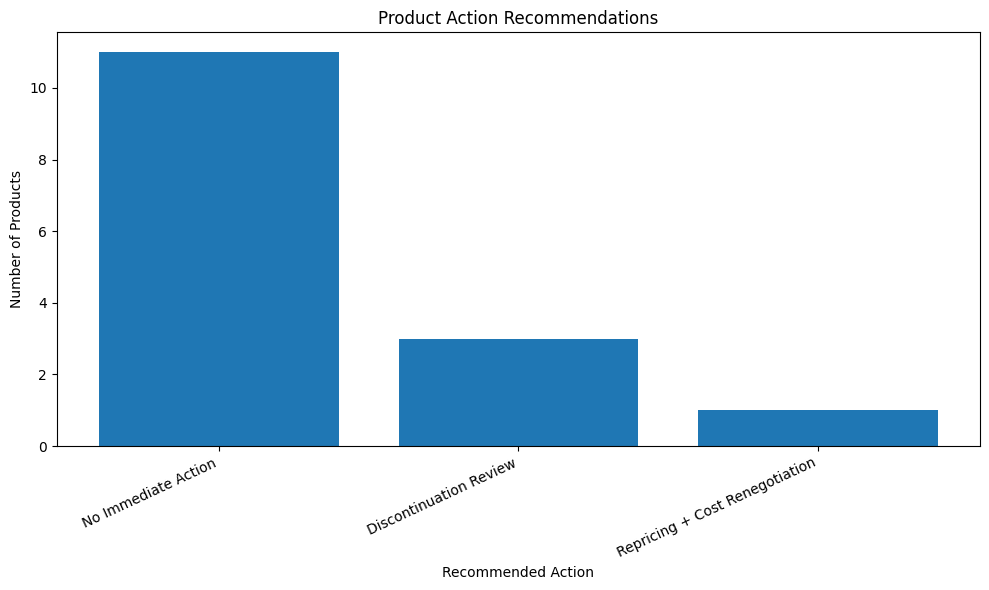

In [ ]:
action_counts = (
    cost_diagnostics["Recommended_Action"]
    .value_counts()
)

plt.figure(figsize=(10, 6))

plt.bar(
    action_counts.index,
    action_counts.values
)

plt.title(
    "Product Action Recommendations"
)

plt.xlabel("Recommended Action")
plt.ylabel("Number of Products")

plt.xticks(
    rotation=25,
    ha="right"
)

plt.tight_layout()

plt.savefig(
    "Cost_Diagnostic_Action_Recommendations.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
cost_diagnostics.to_csv("Cost_Structure_Diagnostics.csv", index = False)

Create Final Summary KPI Report

In [ ]:
cost_diagnostic_summary = pd.DataFrame({

    "Metric": [
        "Total Products",
        "Cost-Heavy Products",
        "Margin-Poor Products",
        "Cost-Heavy & Margin-Poor Products",
        "Pricing Inefficiency Products",
        "Repricing Candidates",
        "Cost Renegotiation Candidates",
        "Discontinuation Review Candidates",
        "Highest Cost-Ratio Product",
        "Highest Cost Ratio (%)",
        "Lowest Margin Product",
        "Lowest Gross Margin (%)"
    ],

    "Result": [
        len(cost_diagnostics),

        int(cost_diagnostics["Cost_Heavy"].sum()),

        int(cost_diagnostics["Margin_Poor"].sum()),

        int(
            (
                cost_diagnostics["Cost_Heavy"] &
                cost_diagnostics["Margin_Poor"]
            ).sum()
        ),

        int(
            cost_diagnostics[
                "Pricing_Inefficiencies"
            ].sum()
        ),

        int(
            cost_diagnostics["Repricing_Flag"].sum()
        ),

        int(
            cost_diagnostics[
                "Cost_Renegotiation_Flag"
            ].sum()
        ),

        int(
            cost_diagnostics[
                "Discontinuation_Review_Flag"
            ].sum()
        ),

        cost_diagnostics.loc[
            cost_diagnostics["Cost_Ratio(%)"].idxmax(),
            "Product Name"
        ],

        round(
            cost_diagnostics["Cost_Ratio(%)"].max(),
            2
        ),

        cost_diagnostics.loc[
            cost_diagnostics["Gross_Margin(%)"].idxmin(),
            "Product Name"
        ],

        round(
            cost_diagnostics["Gross_Margin(%)"].min(),
            2
        )
    ]
})

display(cost_diagnostic_summary)

,Metric,Result
0,Total Products,15
1,Cost-Heavy Products,4
2,Margin-Poor Products,4
3,Cost-Heavy & Margin-Poor Products,4
4,Pricing Inefficiency Products,1
5,Repricing Candidates,1
6,Cost Renegotiation Candidates,4
7,Discontinuation Review Candidates,3
8,Highest Cost-Ratio Product,Kazookles
9,Highest Cost Ratio (%),92.31


Save:


In [ ]:
cost_diagnostic_summary.to_csv(
    "Cost_Diagnostics_Summary.csv",
    index=False
)

Download Report and Chart

In [ ]:
files.download("Cost_Structure_Diagnostics.csv")
files.download("Cost_Diagnostics_Summary.csv")
files.download("Cost_Diagnostic_Action_Recommendations.png")
files.download("Cost_Ratio_vs_Gross_Margin.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

###Margin Volatility Analysis

Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Upload Cleaned Dataset

In [ ]:
from google.colab import files
upload_file = files.upload()

Saving Cleaned_Nassau_Candy_Distributor_Dataset.csv to Cleaned_Nassau_Candy_Distributor_Dataset.csv


In [ ]:
df = pd.read_csv("Cleaned_Nassau_Candy_Distributor_Dataset.csv")

In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,...,Cost,Shipping Days,Flag_Invalid_Sales,Flag_Invalid_Units,Flag_Invalid_Cost,Flag_Invalid_Profit,Flag_Profit_Calculation,Flag_Shipping_Date,Flag_Shipping_Duration,Flag_Overall_Quality
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,...,2.28,909,ok,Ok,Ok,Ok,Ok,Ok,Ok,Valid
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,...,2.60,909,ok,Ok,Ok,Ok,Ok,Ok,Ok,Valid
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,...,3.00,909,ok,Ok,Ok,Ok,Ok,Ok,Ok,Valid
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,...,3.30,909,ok,Ok,Ok,Ok,Ok,Ok,Ok,Valid
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,...,3.90,912,ok,Ok,Ok,Ok,Ok,Ok,Ok,Valid


Convert Order Date

In [ ]:
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    format = "%d-%m-%Y",
    errors = "coerce"
)

Check

In [ ]:
print("Missing Order Dates: ",
      df["Order Date"].isnull().sum()
)

print("Minimun Date: ",
      df["Order Date"].min()
)

print("Maximum Date: ",
      df["Order Date"].max()
)

Missing Order Dates:  0
Minimun Date:  2024-01-02 00:00:00
Maximum Date:  2025-12-31 00:00:00


Create Month Column

In [ ]:
df["Order_Month"] = (
    df["Order Date"].dt.month_name().astype(str)
)

display(
    df[
        [
            "Order Date",
            "Order_Month",
            "Product Name",
            "Sales",
            "Gross Profit"
        ]
    ].head()
)

,Order Date,Order_Month,Product Name,Sales,Gross Profit
0,2024-01-03,January,Wonka Bar - Milk Chocolate,6.50,4.22
1,2024-01-04,January,Wonka Bar - Triple Dazzle Caramel,7.50,4.90
2,2024-01-04,January,Wonka Bar - Nutty Crunch Surprise,10.47,7.47
3,2024-01-04,January,Wonka Bar -Scrumdiddlyumptious,10.80,7.50
4,2024-01-05,January,Wonka Bar - Triple Dazzle Caramel,11.25,7.35


Company-level monthly margin

Monthly Gross Margin = (Total Monthly Gross Profit ÷ Total Monthly Sales) × 100

In [ ]:
company_monthly = (
    df.groupby("Order_Month", as_index=False)
      .agg(
          Monthly_Sales=("Sales", "sum"),
          Monthly_Gross_Profit=("Gross Profit", "sum")
      )
)

company_monthly["Monthly_Gross_Margin(%)"] = (
    company_monthly["Monthly_Gross_Profit"]
    / company_monthly["Monthly_Sales"]
) * 100

display(company_monthly)

,Order_Month,Monthly_Sales,Monthly_Gross_Profit,Monthly_Gross_Margin(%)
0,April,8910.66,5878.91,65.976145
1,August,10217.75,6741.27,65.976071
2,December,21234.48,13977.92,65.826524
3,February,3933.52,2586.14,65.746202
4,January,5583.00,3694.95,66.182160
5,July,9923.05,6548.31,65.990900
6,June,9733.69,6454.61,66.312056
7,March,9562.14,6259.54,65.461706
8,May,10507.20,6944.54,66.093155
9,November,20646.57,13697.97,66.345015


Overall company Margin Volatility

In [ ]:
company_avg_margin = (
    company_monthly[
        "Monthly_Gross_Margin(%)"
    ].mean()
)

company_min_margin = (
    company_monthly[
        "Monthly_Gross_Margin(%)"
    ].min()
)

company_max_margin = (
    company_monthly[
        "Monthly_Gross_Margin(%)"
    ].max()
)

company_margin_volatility = (
    company_monthly[
        "Monthly_Gross_Margin(%)"
    ].std()
)

company_margin_range = (
    company_max_margin
    - company_min_margin
)

company_cv = (
    company_margin_volatility
    / company_avg_margin
) * 100


print(
    f"Average Monthly Margin: "
    f"{company_avg_margin:.2f}%"
)

print(
    f"Margin Volatility (SD): "
    f"{company_margin_volatility:.2f} percentage points"
)

print(
    f"Minimum Monthly Margin: "
    f"{company_min_margin:.2f}%"
)


print(
    f"Margin Range: "
    f"{company_margin_range:.2f} percentage points"
)

print(
    f"Volatility CV: "
    f"{company_cv:.2f}%"
)

print(
    f"Maximum Monthly Margin: "
    f"{company_max_margin:.2f}%"
)

Average Monthly Margin: 65.91%
Margin Volatility (SD): 0.31 percentage points
Minimum Monthly Margin: 65.39%
Margin Range: 0.95 percentage points
Volatility CV: 0.47%
Maximum Monthly Margin: 66.35%


Company Margin Trend Chart

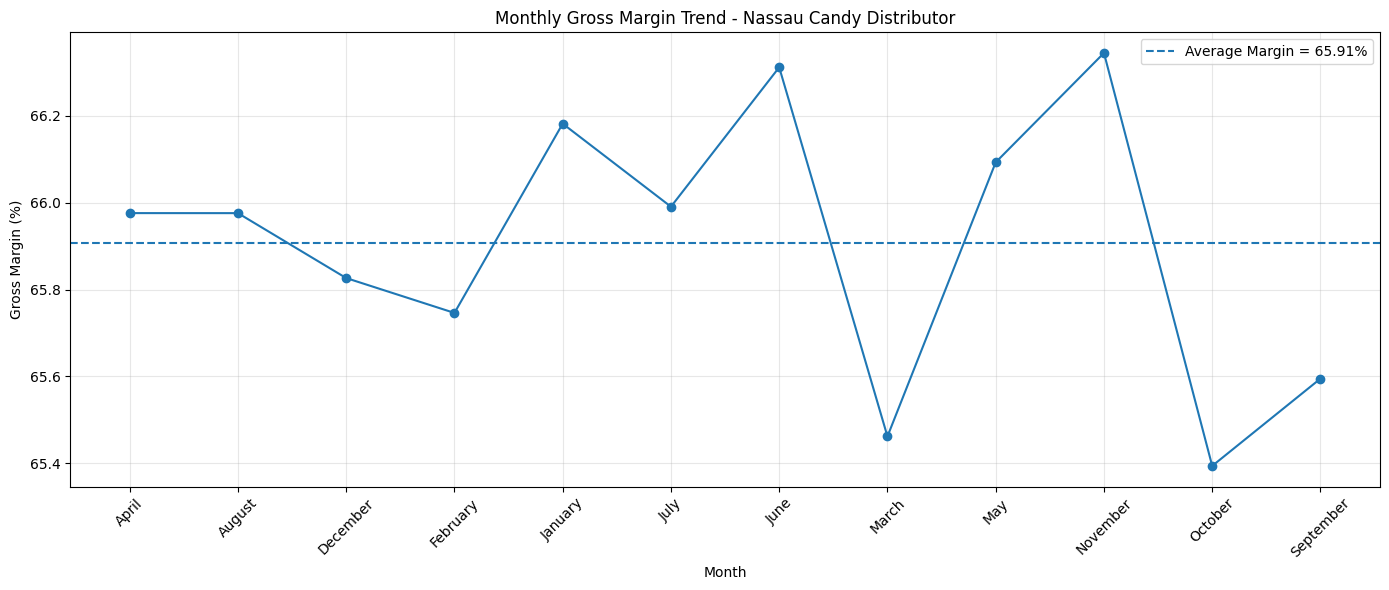

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(
    company_monthly["Order_Month"],
    company_monthly["Monthly_Gross_Margin(%)"],
    marker="o"
)

plt.axhline(
    company_avg_margin,
    linestyle="--",
    label=f"Average Margin = {company_avg_margin:.2f}%"
)

plt.title(
    "Monthly Gross Margin Trend - Nassau Candy Distributor"
)

plt.xlabel("Month")
plt.ylabel("Gross Margin (%)")

plt.xticks(rotation=45)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "Company_Monthly_Margin_Trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Product-level monthly margin

In [ ]:
product_monthly = (
    df.groupby(
        [
            "Product ID",
            "Product Name",
            "Division",
            "Order_Month"
        ],
        as_index=False
    )
    .agg(
        Monthly_Sales=("Sales", "sum"),
        Monthly_Gross_Profit=("Gross Profit", "sum"),
        Monthly_Units=("Units", "sum")
    )
)

Gross Margin:

In [ ]:
product_monthly["Monthly_Gross_Margin(%)"] = np.where(
    product_monthly["Monthly_Sales"] != 0,

    (
        product_monthly["Monthly_Gross_Profit"]
        / product_monthly["Monthly_Sales"]
    ) * 100,

    np.nan
)

Check:

In [ ]:
display(product_monthly.head(20))

,Product ID,Product Name,Division,Order_Month,Monthly_Sales,Monthly_Gross_Profit,Monthly_Units,Monthly_Gross_Margin(%)
0,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Chocolate,April,1576.80,1051.20,438,66.666667
1,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Chocolate,August,1612.80,1075.20,448,66.666667
2,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Chocolate,December,3517.20,2344.80,977,66.666667
3,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Chocolate,February,662.40,441.60,184,66.666667
4,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Chocolate,January,928.80,619.20,258,66.666667
5,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Chocolate,July,1933.20,1288.80,537,66.666667
6,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Chocolate,June,1749.60,1166.40,486,66.666667
7,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Chocolate,March,1616.40,1077.60,449,66.666667
8,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Chocolate,May,1821.60,1214.40,506,66.666667
9,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Chocolate,November,3733.20,2488.80,1037,66.666667


Calculate Product Margin Volatility

In [ ]:
product_volatility = (
    product_monthly
    .groupby(
        [
            "Product ID",
            "Product Name",
            "Division"
        ]
    )
    .agg(
        Active_Months=(
            "Order_Month",
            "nunique"
        ),

        Avg_Monthly_Margin=(
            "Monthly_Gross_Margin(%)",
            "mean"
        ),

        Margin_Volatility_SD=(
            "Monthly_Gross_Margin(%)",
            "std"
        ),

        Min_Monthly_Margin=(
            "Monthly_Gross_Margin(%)",
            "min"
        ),

        Max_Monthly_Margin=(
            "Monthly_Gross_Margin(%)",
            "max"
        )
    )
    .reset_index()
)

Margin range:

In [ ]:
product_volatility["Margin_Range_pp"] = (
    product_volatility["Max_Monthly_Margin"]
    - product_volatility["Min_Monthly_Margin"]
)

Floating-point correction:

In [ ]:
product_volatility[
    "Margin_Volatility_SD"
] = product_volatility[
    "Margin_Volatility_SD"
].fillna(0)

product_volatility.loc[
    product_volatility[
        "Margin_Volatility_SD"
    ].abs() < 1e-10,

    "Margin_Volatility_SD"
] = 0

Sort:

In [ ]:
product_volatility = (
    product_volatility
    .sort_values(
        "Margin_Volatility_SD",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    product_volatility.round(2)
)

,Product ID,Product Name,Division,Active_Months,Avg_Monthly_Margin,Margin_Volatility_SD,Min_Monthly_Margin,Max_Monthly_Margin,Margin_Range_pp
0,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Chocolate,12,66.67,0.0,66.67,66.67,0.0
1,CHO-MIL-31000,Wonka Bar - Milk Chocolate,Chocolate,12,64.92,0.0,64.92,64.92,0.0
2,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,Chocolate,12,71.35,0.0,71.35,71.35,0.0
3,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,Chocolate,12,69.44,0.0,69.44,69.44,0.0
4,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,Chocolate,12,65.33,0.0,65.33,65.33,0.0
5,OTH-FIZ-56000,Fizzy Lifting Drinks,Sugar,5,60.00,0.0,60.00,60.00,0.0
6,OTH-GUM-21000,Wonka Gum,Other,12,52.00,0.0,52.00,52.00,0.0
7,OTH-KAZ-38000,Kazookles,Other,12,7.69,0.0,7.69,7.69,0.0
8,OTH-LIC-15000,Lickable Wallpaper,Other,12,50.00,0.0,50.00,50.00,0.0
9,SUG-EVE-47000,Everlasting Gobstopper,Sugar,3,80.00,0.0,80.00,80.00,0.0


Product Volatility Risk classification

* SD <= 1 pp      → Low Volatility
* 1 < SD <= 5 pp  → Moderate Volatility
* SD > 5 pp       → High Volatility

In [ ]:
def volatility_category(sd):

    if sd <= 1:
        return "Low Volatility"

    elif sd <= 5:
        return "Moderate Volatility"

    else:
        return "High Volatility"


product_volatility[
    "Volatility_Category"
] = product_volatility[
    "Margin_Volatility_SD"
].apply(volatility_category)

Display:

In [ ]:
display(
    product_volatility[
        [
            "Product Name",
            "Division",
            "Active_Months",
            "Avg_Monthly_Margin",
            "Margin_Volatility_SD",
            "Margin_Range_pp",
            "Volatility_Category"
        ]
    ].round(2)
)

,Product Name,Division,Active_Months,Avg_Monthly_Margin,Margin_Volatility_SD,Margin_Range_pp,Volatility_Category
0,Wonka Bar - Fudge Mallows,Chocolate,12,66.67,0.0,0.0,Low Volatility
1,Wonka Bar - Milk Chocolate,Chocolate,12,64.92,0.0,0.0,Low Volatility
2,Wonka Bar - Nutty Crunch Surprise,Chocolate,12,71.35,0.0,0.0,Low Volatility
3,Wonka Bar -Scrumdiddlyumptious,Chocolate,12,69.44,0.0,0.0,Low Volatility
4,Wonka Bar - Triple Dazzle Caramel,Chocolate,12,65.33,0.0,0.0,Low Volatility
5,Fizzy Lifting Drinks,Sugar,5,60.00,0.0,0.0,Low Volatility
6,Wonka Gum,Other,12,52.00,0.0,0.0,Low Volatility
7,Kazookles,Other,12,7.69,0.0,0.0,Low Volatility
8,Lickable Wallpaper,Other,12,50.00,0.0,0.0,Low Volatility
9,Everlasting Gobstopper,Sugar,3,80.00,0.0,0.0,Low Volatility


Division-level monthly margin

In [ ]:
division_monthly = (
    df.groupby(
        [
            "Division",
            "Order_Month"
        ],
        as_index=False
    )
    .agg(
        Monthly_Sales=("Sales", "sum"),
        Monthly_Gross_Profit=("Gross Profit", "sum")
    )
)

division_monthly["Monthly_Gross_Margin(%)"] = (
    division_monthly["Monthly_Gross_Profit"]
    / division_monthly["Monthly_Sales"]
) * 100

display(division_monthly)

,Division,Order_Month,Monthly_Sales,Monthly_Gross_Profit,Monthly_Gross_Margin(%)
0,Chocolate,April,8398.17,5663.17,67.433381
1,Chocolate,August,9692.75,6517.87,67.244796
2,Chocolate,December,19474.50,13161.94,67.585509
3,Chocolate,February,3587.77,2427.79,67.668496
4,Chocolate,January,5365.26,3599.26,67.084540
5,Chocolate,July,9353.55,6307.21,67.431189
6,Chocolate,June,9272.19,6237.81,67.274398
7,Chocolate,March,8790.70,5930.20,67.459929
8,Chocolate,May,9890.70,6674.84,67.486022
9,Chocolate,November,19637.71,13257.61,67.510978


Division Margin Volatility

In [ ]:
division_volatility = (
    division_monthly
    .groupby("Division")
    .agg(
        Active_Months=(
            "Order_Month",
            "nunique"
        ),

        Avg_Monthly_Margin=(
            "Monthly_Gross_Margin(%)",
            "mean"
        ),

        Margin_Volatility_SD=(
            "Monthly_Gross_Margin(%)",
            "std"
        ),

        Min_Monthly_Margin=(
            "Monthly_Gross_Margin(%)",
            "min"
        ),

        Max_Monthly_Margin=(
            "Monthly_Gross_Margin(%)",
            "max"
        )
    )
    .reset_index()
)

Risk:

In [ ]:
division_volatility[
    "Volatility_Category"
] = division_volatility[
    "Margin_Volatility_SD"
].apply(volatility_category)

Display:

In [ ]:
division_volatility = (
    division_volatility
    .sort_values(
        "Margin_Volatility_SD",
        ascending=False
    )
)

display(
    division_volatility.round(2)
)

,Division,Active_Months,Avg_Monthly_Margin,Margin_Volatility_SD,Min_Monthly_Margin,Max_Monthly_Margin
2,Sugar,11,62.59,11.96,46.67,80.00
1,Other,12,43.75,2.53,40.70,48.05
0,Chocolate,12,67.43,0.16,67.08,67.67


Division Margin Trend Chart

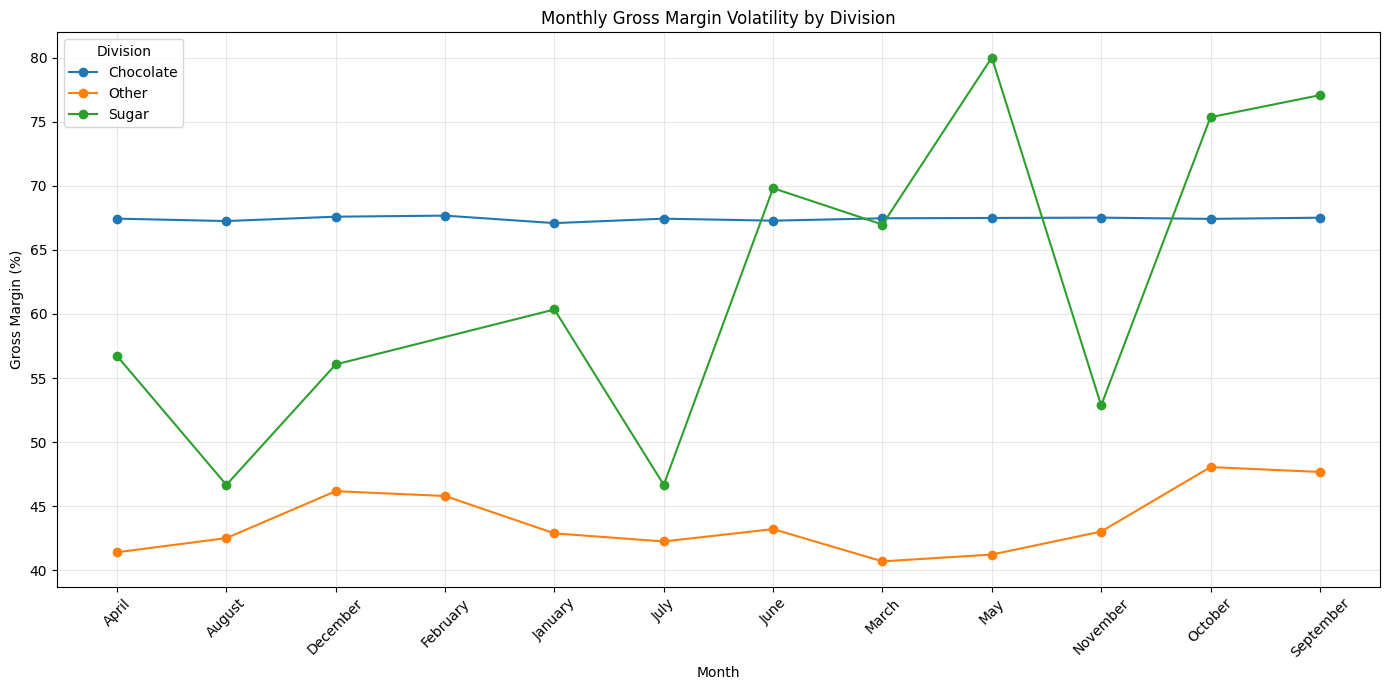

In [ ]:
plt.figure(figsize=(14, 7))

for division in division_monthly["Division"].unique():

    temp = division_monthly[
        division_monthly["Division"] == division
    ]

    plt.plot(
        temp["Order_Month"],
        temp["Monthly_Gross_Margin(%)"],
        marker="o",
        label=division
    )

plt.title(
    "Monthly Gross Margin Volatility by Division"
)

plt.xlabel("Month")
plt.ylabel("Gross Margin (%)")

plt.xticks(rotation=45)

plt.legend(title="Division")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "Division_Margin_Volatility_Trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Division Volatility Comparison Chart

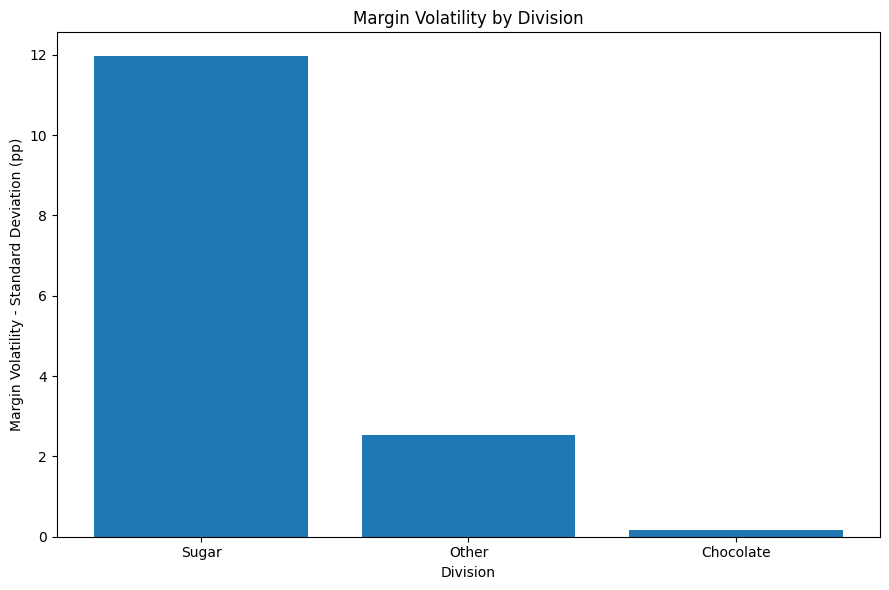

In [ ]:
division_chart = (
    division_volatility
    .sort_values(
        "Margin_Volatility_SD",
        ascending=False
    )
)

plt.figure(figsize=(9, 6))

plt.bar(
    division_chart["Division"],
    division_chart["Margin_Volatility_SD"]
)

plt.title(
    "Margin Volatility by Division"
)

plt.xlabel("Division")

plt.ylabel(
    "Margin Volatility - Standard Deviation (pp)"
)

plt.tight_layout()

plt.savefig(
    "Division_Margin_Volatility.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Identify Most / Least Volatile Division

In [ ]:
most_volatile = division_volatility.loc[
    division_volatility[
        "Margin_Volatility_SD"
    ].idxmax()
]

least_volatile = division_volatility.loc[
    division_volatility[
        "Margin_Volatility_SD"
    ].idxmin()
]

print(
    "Most Volatile Division:",
    most_volatile["Division"]
)

print(
    f"Volatility SD: "
    f"{most_volatile['Margin_Volatility_SD']:.2f} pp"
)

print()

print(
    "Most Stable Division:",
    least_volatile["Division"]
)

print(
    f"Volatility SD: "
    f"{least_volatile['Margin_Volatility_SD']:.2f} pp"
)

Most Volatile Division: Sugar
Volatility SD: 11.96 pp

Most Stable Division: Chocolate
Volatility SD: 0.16 pp


Find minimum and maximum margin month

In [ ]:
for division in division_monthly["Division"].unique():

    temp = division_monthly[
        division_monthly["Division"] == division
    ]

    lowest = temp.loc[
        temp["Monthly_Gross_Margin(%)"].idxmin()
    ]

    highest = temp.loc[
        temp["Monthly_Gross_Margin(%)"].idxmax()
    ]

    print("\nDivision:", division)

    print(
        f"Lowest Margin: "
        f"{lowest['Order_Month']} "
        f"({lowest['Monthly_Gross_Margin(%)']:.2f}%)"
    )

    print(
        f"Highest Margin: "
        f"{highest['Order_Month']} "
        f"({highest['Monthly_Gross_Margin(%)']:.2f}%)"
    )


Division: Chocolate
Lowest Margin: January (67.08%)
Highest Margin: February (67.67%)

Division: Other
Lowest Margin: March (40.70%)
Highest Margin: October (48.05%)

Division: Sugar
Lowest Margin: August (46.67%)
Highest Margin: May (80.00%)


Create final Margin Volatility Summary

In [ ]:
margin_volatility_summary = pd.DataFrame({

    "Metric": [

        "Analysis Period",

        "Company Average Monthly Margin (%)",

        "Company Margin Volatility SD (pp)",

        "Company Minimum Monthly Margin (%)",

        "Company Maximum Monthly Margin (%)",

        "Company Margin Range (pp)",

        "Most Volatile Division",

        "Highest Division Volatility SD (pp)",

        "Most Stable Division",

        "Lowest Division Volatility SD (pp)",

        "Product-Level Margin Volatility",

        "Overall Margin Stability"
    ],

    "Result": [

        f"{df['Order Date'].min().date()} "
        f"to {df['Order Date'].max().date()}",

        round(company_avg_margin, 2),

        round(company_margin_volatility, 2),

        round(company_min_margin, 2),

        round(company_max_margin, 2),

        round(company_margin_range, 2),

        most_volatile["Division"],

        round(
            most_volatile[
                "Margin_Volatility_SD"
            ],
            2
        ),

        least_volatile["Division"],

        round(
            least_volatile[
                "Margin_Volatility_SD"
            ],
            2
        ),

        "Effectively Zero for all products",

        "Stable at company level"
    ]
})

display(margin_volatility_summary)

,Metric,Result
0,Analysis Period,2024-01-02 to 2025-12-31
1,Company Average Monthly Margin (%),65.91
2,Company Margin Volatility SD (pp),0.31
3,Company Minimum Monthly Margin (%),65.39
4,Company Maximum Monthly Margin (%),66.35
5,Company Margin Range (pp),0.95
6,Most Volatile Division,Sugar
7,Highest Division Volatility SD (pp),11.96
8,Most Stable Division,Chocolate
9,Lowest Division Volatility SD (pp),0.16


Save:

In [ ]:
company_monthly.to_csv(
    "Monthly_Company_Margin.csv",
    index=False
)

product_monthly.to_csv(
    "Monthly_Product_Margins.csv",
    index=False
)

product_volatility.to_csv(
    "Product_Margin_Volatility_Report.csv",
    index=False
)

division_monthly.to_csv(
    "Monthly_Division_Margins.csv",
    index=False
)

division_volatility.to_csv(
    "Division_Margin_Volatility_Report.csv",
    index=False
)

margin_volatility_summary.to_csv(
    "Margin_Volatility_Analysis_Summary.csv",
    index=False
)

print("All Margin Volatility reports saved successfully.")

All Margin Volatility reports saved successfully.


Downloaded:

In [ ]:
# KPI / Report CSV files
files.download("Monthly_Company_Margin.csv")
files.download("Product_Margin_Volatility_Report.csv")
files.download("Division_Margin_Volatility_Report.csv")
files.download("Margin_Volatility_Analysis_Summary.csv")

# Chart files
files.download("Company_Monthly_Margin_Trend.png")
files.download("Division_Margin_Volatility_Trend.png")
files.download("Division_Margin_Volatility.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>